# 📦 **Shanta Gold Au Recovery Modelling Notebook**

This notebook develops a forward-looking model of daily NaCN addition for Shanta Gold’s leaching circuit, using only features known before dosing. It supports operational planning, anomaly detection, and optimisation of reagent consumption.

#### 🎯 Objective
**Predict the optimal cyanide addition (kg/day)** based on:
* Feed characteristics (grade, throughput, O₂, particle size)
* Recovery and tailings CN constraints

> Unlike typical retrospective models, this one is forward-looking: it aims to predict what needs to happen — not just explain what already occurred.

#### 🔍 Feature Scope
Focus on features:
* ✅ Known **before** leaching (e.g. feed grade, particle size distribution)
* ✅ **Stable or test-derived** inputs (e.g. gold grain size, locked fraction)
* ❌ Exclude real-time or output-dependent features (e.g. tailings CN, live cyanide probes)

#### 📌 Included Inputs
* `Leach_Feed_Grade_Au_Gt_Day`
* `Leach_Feed_Throughput_M3Day`
* `Leach_Feed_Gt_150um_Day`, `Leach_Feed_Gt_75um_Day`, `Leach_Feed_Lt_75um_Day`
* `O2_ppm` (or estimated dosage)
* Site constants:
	- Gold grain size
	- Locked Au fraction
	- Liberation curve type

#### 🧹 Excluded Features
* **`Cyanide_Profile_Ppm_`*** – real-time values not available before dosing
* **`Estimated_CN_ppm`, `CN_ppm`** – derived from dosing
* **`Tailings CN`, `Au Recovery`** – these are model targets, not predictors

#### 🧠 Modelling Strategy
**⚒️ Feature Engineering Before Model Swapping**
* Add interaction terms (e.g. Grade × O₂, Throughput / FinesFraction)
* Use particle/gold size mismatch to estimate theoretical recovery
* Segment by supplier or time periods for better stratification

**🧪 Physics-Guided Hybrid Modelling**
* Use Lima & Hodouin kinetic model to estimate baseline CN demand
* Train the ML model to predict deviation from baseline (i.e. residual over/under-dosing)

#### ⚠️ Uncertainty and Practical Use
Given site data is:
* Noisy, sparse, and aggregated
* Impacted by unmeasured variables (e.g. mineralogy, reagent speciation, operator practice)
It's often more effective to:
* Predict **ranges or risk levels** (e.g. high/med/low CN demand)
* Use the model for **planning and guidance**, not precise control

#### 🧭 Summary of Modelling Approach
| **Step** | **Action**                                                           |
| ---- | ------------------------------------------------------------------------ |
| 1️⃣  | Clean inputs – remove non-causal or output-derived fields                |
| 2️⃣  | Engineer interactions and composite predictors                           |
| 3️⃣  | Add metadata (e.g. supplier batch flag, CN quality proxy)                |
| 4️⃣  | Apply L\&H model to compute baseline, then model deviation               |
| 5️⃣  | Evaluate based on decision-support value, not just error metrics         |


## 📂 Load Data & Initial Setup

This section loads the dataset(s), sets up basic packages and display settings, and ensures a consistent environment for downstream analysis.

Tasks:
- Import required libraries (Pandas, NumPy, Matplotlib, etc.)
- Load raw data files (e.g. CSV, Excel, Parquet)
- Parse dates and set index (if applicable)
- Configure Pandas display options and global warnings

> Ensure file paths and date formats are correct before proceeding.

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from xgboost import XGBRegressor
import shap
import joblib
import seaborn as sns
from typing import Callable, List, Tuple
from scipy.optimize import brentq, minimize_scalar, minimize
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.api as sm
from leaching_functions import (
    simulate_lh_recovery_fitted, calc_gold_dissolution_rate, simulate_recovery_through_tanks
)
import plotting_functions as pf

In [2]:
df = pd.read_csv('shanta_usage_data.csv')

# Convert 'date' column to datetime
df['Date'] = pd.to_datetime(df['Date'])

## ⚙️ Define Constants & User Parameters

This section defines model constants, site-specific assumptions, and user-configurable parameters.

Includes:
- Physical constants or site-specific values (e.g. density, locked gold %, grain size)
- Configurable thresholds for model filtering or grouping
- Toggles to enable/disable specific modelling behaviours

> These parameters drive key behaviours in cleansing, feature engineering, and modelling stages.

In [ ]:
# Define random seed for reproducibility
random_seed = 13

# Define static tank volumes
tank_config = {
	"Cyanide_Profile_Ppm_Leach_Tank_1": 1000,
	"Cyanide_Profile_Ppm_Leach_Tank_2": 1000,
	"Cyanide_Profile_Ppm_Cil_Tank_1": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_2": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_3": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_4": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_5": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_6": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_7": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_8": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_9": 250,
}
total_circuit_volume = sum(tank_config.values())	# total volume of the leaching circuit in m³

# Define constants for ore characteristics
d = 20 												# ore particle size µm
particle_size_threshold = 50 						# µm (particles larger than this are considered coarse)
locked_gold_threshold = 0.02 						# 2% gold remains locked in the ore after leaching
liberation_fraction = 1 - locked_gold_threshold		# fraction of gold that is liberated and available for leaching
density = 2.7  										# t/m³ (typical for gold ore)

# Define constants for leaching process
n_tanks = 11										# number of tanks in the leaching circuit	
total_residence_time = 30 							# total residence time in hours
min_cn_conc = 100 									# minimum cyanide concentration in ppm
max_cn_conc = 1000 									# maximum cyanide concentration in ppm
cn_decay_factor = 0.85  				# % CN that remains from one tank to the next in the series
max_nacn_drawdown = 12
max_dissolution_rate = 100				# maximum gold dissolution rate in mg/kg/h
outlier_thresholds = {
	'Nacn_Used_T': (0, 10),  						# t NaCN used per day
	'Daily_Nacn_Consumption_Kgt': (0, 10),			# kg NaCN consumed per tonne of ore
	'MTD_Nacn_Consumption_Kgt': (0, 10)				# kg NaCN consumed per tonne of ore
}
o2_smoothing_window = 45							# smoothing window for O2 data
pulp_density = 1.5  								# kg/L
constant_pulp_density = True 						# use constant pulp density based on ore type
total_residence_time = 30 							# hours
solid_density = 2.7  								# t/m³
liquid_density = 1.0  								# t/m³ (mostly water, even after dilution)

# Feed charateristics
ultra_fine_sizing = 50	 							# midpoint for < 75 µm sizing
fine_sizing = 112.5									# midpoint for > 75 µm sizing
coarse_sizing = 175 								# midpoint for > 150 µm sizing

## 📊 Define Plotting Helpers

Reusable plotting functions for visual diagnostics and model evaluation.

Includes:
- Scatter plots and residual plots
- Trend overlays and prediction vs actual charts
- Monthly or period summaries
- Heatmaps and interaction visualisations

> Use these throughout the notebook to keep visual logic consistent and concise.

In [4]:
# # --- Plotting Helper Functions ---

# def plot_bar_error(x, y, title, xlabel, ylabel):
# 	"""
# 	Bar plot of error or difference values.

# 	Parameters:
# 	- x: x-axis values (e.g., categories or dates)
# 	- y: y-axis values (e.g., % error or differences)
# 	- title: plot title
# 	- xlabel: label for x-axis
# 	- ylabel: label for y-axis
# 	"""
# 	plt.figure(figsize=(12, 6))
# 	plt.bar(x, y, color="skyblue")
# 	plt.axhline(0, color='red', linestyle='--', linewidth=1)  # zero reference line
# 	plt.title(title)
# 	plt.xlabel(xlabel)
# 	plt.ylabel(ylabel)
# 	plt.xticks(rotation=45)
# 	plt.tight_layout()
# 	plt.show()


# def plot_line_with_error_bands(x, y1, y2, title, xlabel, ylabel,
# 							   y1_label="Reported", y2_label="Estimated"):
# 	"""
# 	Line plot with two series and shaded error band.

# 	Parameters:
# 	- x: x-axis values
# 	- y1: first line series (e.g., reported values)
# 	- y2: second line series (e.g., estimated values)
# 	- title, xlabel, ylabel: plot metadata
# 	- y1_label, y2_label: legend labels
# 	"""
# 	plt.figure(figsize=(12, 6))
# 	plt.plot(x, y1, label=y1_label, marker='o')
# 	plt.plot(x, y2, label=y2_label, marker='s')
# 	plt.fill_between(x, y1, y2, color='gray', alpha=0.3, label="Error Band")  # shaded error area
# 	plt.title(title)
# 	plt.xlabel(xlabel)
# 	plt.ylabel(ylabel)
# 	plt.xticks(rotation=45)
# 	plt.legend()
# 	plt.grid(True)
# 	plt.tight_layout()
# 	plt.show()


# def plot_scatter_with_regression(x, y, title, xlabel, ylabel):
# 	"""
# 	Scatter plot with fitted regression line.

# 	Parameters:
# 	- x, y: data points
# 	- title, xlabel, ylabel: plot metadata
# 	"""
# 	plt.figure(figsize=(6, 5))
# 	plt.scatter(x, y, alpha=0.6)
# 	regression_line = np.poly1d(np.polyfit(x, y, 1))
# 	plt.plot(np.unique(x), regression_line(np.unique(x)), color='red', linewidth=2)
# 	plt.title(title)
# 	plt.xlabel(xlabel)
# 	plt.ylabel(ylabel)
# 	plt.grid(True)
# 	plt.tight_layout()
# 	plt.show()


# def plot_multiple_lines(df, x_col, y_series, title="Line Plot", x_label="X", y_label="Y", colours=None):
# 	"""
# 	Plot multiple time series or variables on the same line plot.

# 	Parameters:
# 	- df: DataFrame containing data
# 	- x_col: column name for x-axis
# 	- y_series: list of dicts with keys:
# 		- 'col': y column name
# 		- 'label': label for legend
# 		- 'style': dict of matplotlib style options (optional)
# 	- title, x_label, y_label: plot metadata
# 	- colours: list of colours to apply to each line (optional)
# 	"""
# 	plt.figure(figsize=(12, 6))
	
# 	for i, series in enumerate(y_series):
# 		y_col = series["col"]
# 		label = series.get("label", y_col)
# 		style = series.get("style", {})
# 		colour = colours[i] if colours and i < len(colours) else None
# 		plt.plot(df[x_col], df[y_col], label=label, color=colour, **style)

# 	plt.title(title)
# 	plt.xlabel(x_label)
# 	plt.ylabel(y_label)
# 	plt.xticks(rotation=45)
# 	plt.grid(True)
# 	plt.legend()
# 	plt.tight_layout()
# 	plt.show()


# def plot_actual_vs_predicted_scatter(y_actual, y_pred, title="Model Performance",
# 									 xlabel="Actual", ylabel="Predicted"):
# 	"""
# 	Scatter plot comparing actual vs predicted values with a y = x reference line.

# 	Parameters:
# 	- y_actual: true values
# 	- y_pred: predicted values
# 	- title, xlabel, ylabel: plot metadata
# 	"""
# 	plt.figure(figsize=(6, 5))
# 	plt.scatter(y_actual, y_pred, alpha=0.6)
# 	min_val = min(y_actual.min(), y_pred.min())
# 	max_val = max(y_actual.max(), y_pred.max())
# 	plt.plot([min_val, max_val], [min_val, max_val], 'r--')  # y = x reference
# 	plt.xlabel(xlabel)
# 	plt.ylabel(ylabel)
# 	plt.title(title)
# 	plt.grid(True)
# 	plt.tight_layout()
# 	plt.show()


# def plot_residuals(y_actual, residuals, title="Residuals vs Actual",
# 				   xlabel="Actual", ylabel="Residual (Actual − Predicted)",
# 				   alpha=0.6):
# 	"""
# 	Scatter plot of residuals (error) vs actual values.

# 	Parameters:
# 	- y_actual: true values
# 	- residuals: actual - predicted
# 	- title, xlabel, ylabel: plot metadata
# 	- alpha: transparency for points
# 	"""
# 	plt.figure(figsize=(7, 5))
# 	plt.scatter(y_actual, residuals, alpha=alpha)
# 	plt.axhline(0, color='red', linestyle='--')  # zero residual reference
# 	plt.xlabel(xlabel)
# 	plt.ylabel(ylabel)
# 	plt.title(title)
# 	plt.grid(True)
# 	plt.tight_layout()
# 	plt.show()
	
# def plot_residuals_over_time(df, date_col="Date", residual_col="Residual",
# 							 title="Residuals Over Time", xlabel="Date", ylabel="Residual (Actual − Predicted)"):
# 	"""
# 	Line plot of residuals over time with zero reference line.

# 	Parameters:
# 	- df: DataFrame containing date and residual columns
# 	- date_col: column name representing dates
# 	- residual_col: column name for residual values
# 	- title, xlabel, ylabel: plot metadata
# 	"""
# 	plt.figure(figsize=(12, 4))
# 	plt.plot(df[date_col], df[residual_col], marker='o', linestyle='-', alpha=0.7)
# 	plt.axhline(0, color='red', linestyle='--')
# 	plt.title(title)
# 	plt.xlabel(xlabel)
# 	plt.ylabel(ylabel)
# 	plt.tight_layout()
# 	plt.grid(True)
# 	plt.show()

# def plot_usage_with_outliers(df, date_col="Date",
# 							 actual_col="Calc_NaCN_Used_Kg",
# 							 predicted_col="Predicted_NaCN_Used_kg",
# 							 outlier_col="Outlier",
# 							 title="NaCN Usage with Outlier Days Highlighted",
# 							 xlabel="Date", ylabel="NaCN Used (kg)"):
# 	"""
# 	Line plot of actual vs predicted NaCN usage with outliers highlighted.

# 	Parameters:
# 	- df: DataFrame containing time series and outlier flag
# 	- date_col: column with dates
# 	- actual_col: actual usage column
# 	- predicted_col: predicted usage column
# 	- outlier_col: boolean column indicating outliers
# 	- title, xlabel, ylabel: plot metadata
# 	"""
# 	plt.figure(figsize=(14, 6))
	
# 	# Plot actual and predicted usage
# 	plt.plot(df[date_col], df[actual_col], label="Actual", color="black", linewidth=1.5)
# 	plt.plot(df[date_col], df[predicted_col], label="Predicted", color="green", linewidth=1.5)
	
# 	# Highlight outliers
# 	plt.scatter(df.loc[df[outlier_col], date_col],
# 				df.loc[df[outlier_col], actual_col],
# 				color="red", label="Outliers", zorder=5)
	
# 	plt.xlabel(xlabel)
# 	plt.ylabel(ylabel)
# 	plt.title(title)
# 	plt.legend()
# 	plt.grid(True)
# 	plt.tight_layout()
# 	plt.show()

# def plot_grouped_dual_line_comparison(
# 	df: pd.DataFrame,
# 	group_by: str,
# 	generate_lines_fn: Callable[[pd.DataFrame], Tuple[List[str], dict]],
# 	title_fn: Callable[[str], str] = lambda g: str(g),
# 	ylabel: str = "Value",
# 	xlabel: str = "X-Axis",
# 	legend_labels: List[str] = None,
# 	ncols: int = 3,
# 	figsize: Tuple[int, int] = (18, 4),
# ):
# 	"""
# 	Generic plotting function for grouped line comparisons.

# 	Parameters:
# 		df (pd.DataFrame): Source dataframe
# 		group_by (str): Column name to group by (e.g. 'Month')
# 		generate_lines_fn (Callable): Function that returns (x_labels, y_lines_dict)
# 		title_fn (Callable): Function to convert group key into subplot title
# 		ylabel (str): Label for y-axis
# 		xlabel (str): Label for x-axis
# 		legend_labels (List[str]): Custom legend labels (overrides dict keys if given)
# 		ncols (int): Number of columns in subplot grid
# 		figsize (Tuple): Base (width, height) per row of the subplot grid
# 	"""
# 	df[group_by] = pd.to_datetime(df["Date"]).dt.to_period("M")
# 	grouped = df.groupby(group_by)

# 	n_groups = len(grouped)
# 	nrows = int(np.ceil(n_groups / ncols))
# 	fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0], figsize[1] * nrows), sharey=True)
# 	axes = axes.flatten()

# 	for i, (group_key, group_df) in enumerate(grouped):
# 		x_labels, lines_dict = generate_lines_fn(group_df)

# 		ax = axes[i]
# 		for j, (label, y_values) in enumerate(lines_dict.items()):
# 			display_label = legend_labels[j] if legend_labels and j < len(legend_labels) else label
# 			colour = def_colours[j % len(def_colours)]
# 			ax.plot(x_labels, y_values, label=display_label, marker='o', color=colour)

# 		ax.set_title(title_fn(group_key))
# 		ax.set_xlabel(xlabel)
# 		ax.set_ylabel(ylabel)
# 		ax.set_xticks(range(len(x_labels)))
# 		ax.set_xticklabels(x_labels, rotation=45)
# 		ax.grid(True)
# 		ax.legend()

# 	for j in range(i + 1, len(axes)):
# 		fig.delaxes(axes[j])

# 	plt.tight_layout()
# 	plt.show()


# def plot_heatmap(
# 	df: pd.DataFrame,
# 	x_field: str,
# 	y_field: str,
# 	z_field: str,
# 	x_label: str = "X Axis",
# 	y_label: str = "Y Axis",
# 	z_label: str = "Z Axis (Value)",
# 	title: str = None,
# 	bins: int = 30
# 	):
	
# 	"""
# 	Heatmap of a field against two other fields, using binned statistics.
	
# 	Parameters:
# 	- df: DataFrame containing the data
# 	- x_field: column name for x-axis
# 	- y_field: column name for y-axis
# 	- z_field: column name for z-axis (values to plot)
# 	- x_label: label for x-axis
# 	- y_label: label for y-axis
# 	- z_label: label for z-axis
# 	- bins: number of bins to use for both x and y axes (default is 30)

# 	"""
# 	import matplotlib.pyplot as plt
# 	import numpy as np
# 	from scipy.stats import binned_statistic_2d

# 	# Drop rows with missing values
# 	df_clean = df[[x_field, y_field, z_field]].dropna().copy()
# 	df_clean["z_scaled"] = df_clean[z_field] * 100

# 	# Define bins
# 	x_bins = np.linspace(df_clean[x_field].min(), df_clean[x_field].max(), bins)
# 	y_bins = np.linspace(df_clean[y_field].min(), df_clean[y_field].max(), bins)

# 	# Compute 2D mean statistics
# 	stat, x_edges, y_edges, _ = binned_statistic_2d(
# 		df_clean[x_field], df_clean[y_field], df_clean["z_scaled"],
# 		statistic="mean", bins=[x_bins, y_bins]
# 	)

# 	# Center points for labels
# 	Xc, Yc = np.meshgrid((x_edges[:-1] + x_edges[1:]) / 2,
# 						 (y_edges[:-1] + y_edges[1:]) / 2)

# 	# Plot heatmap
# 	fig, ax = plt.subplots(figsize=(10, 8))
# 	c = ax.pcolormesh(Xc, Yc, stat.T, shading='auto', cmap='viridis')
# 	fig.colorbar(c, ax=ax, label=z_label)
# 	ax.set_xlabel(x_label)
# 	ax.set_ylabel(y_label)
# 	title = (f"Heatmap of {z_label} by {x_label} and {y_label}") if title is None else title
# 	ax.set_title(title)

# 	# Overlay labels
# 	for i in range(stat.T.shape[0]):
# 		for j in range(stat.T.shape[1]):
# 			value = stat.T[i, j]
# 			if not np.isnan(value):
# 				ax.text(Xc[i, j], Yc[i, j], f"{int(round(value))}",
# 						ha='center', va='center', fontsize=7,
# 						color='white', weight='bold')

# 	plt.tight_layout()
# 	plt.show()


# def plot_surface(
# 	df: pd.DataFrame,
# 	x_field: str,
# 	y_field: str,
# 	z_field: str,
# 	x_label: str = "X Axis",
# 	y_label: str = "Y Axis",
# 	z_label: str = "Z Axis (Value)",
# 	title: str = "3D Surface Plot",
# 	grid_points: int = 100,
# 	clip_range: tuple = (70, 95)
# 	):
# 	"""
# 	3D surface plot of a field against two other fields.

# 	Parameters:
# 	- df: DataFrame containing the data
# 	- x_field: column name for x-axis
# 	- y_field: column name for y-axis
# 	- z_field: column name for z-axis (values to plot)
# 	- x_label: label for x-axis
# 	- y_label: label for y-axis
# 	- z_label: label for z-axis
# 	- grid_points: number of points in each dimension for the grid
# 	- clip_range: tuple specifying the range to clip z values (default is (70, 95))

# 	"""

# 	import matplotlib.pyplot as plt
# 	import numpy as np
# 	from scipy.interpolate import griddata
# 	from mpl_toolkits.mplot3d import Axes3D

# 	# Drop rows with missing values
# 	df_clean = df[[x_field, y_field, z_field]].dropna().copy()
# 	df_clean["z_scaled"] = df_clean[z_field] * 100

# 	x = df_clean[x_field].values
# 	y = df_clean[y_field].values
# 	z = df_clean["z_scaled"].values

# 	# Create meshgrid
# 	xi = np.linspace(x.min(), x.max(), grid_points)
# 	yi = np.linspace(y.min(), y.max(), grid_points)
# 	Xi, Yi = np.meshgrid(xi, yi)

# 	# Interpolate and clip
# 	Zi = griddata((x, y), z, (Xi, Yi), method='linear')
# 	Zi = np.clip(Zi, clip_range[0], clip_range[1])

# 	# Plot surface
# 	fig = plt.figure(figsize=(10, 7))
# 	ax = fig.add_subplot(111, projection='3d')
# 	surf = ax.plot_surface(Xi, Yi, Zi, cmap='viridis', edgecolor='none')
# 	fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label=z_label)
# 	ax.set_xlabel(x_label)
# 	ax.set_ylabel(y_label)
# 	ax.set_zlabel(z_label)
# 	ax.set_title(title)
# 	plt.tight_layout()
# 	plt.show()




# PART 2

## 🧰 Feature Engineering

This section derives new features to enhance model performance.

Common operations:
- Create interaction terms (e.g. Grade × FinesFraction, Throughput / PSD)
- Extract temporal or operational flags (e.g. shift, supplier batch, post-changeover)
- Apply physical models to derive baseline expectations (e.g. Lima & Hodouin CN demand)
- Categorise variables into bands or strata (e.g. High/Med/Low O₂)

> Thoughtful feature engineering often yields more benefit than swapping models.

kinetic recovery function, based on the gold leaching kinetics from de Andrade Lima & Hodouin (2005). This model uses the following general form for recovery in each tank:

$$Δ𝑅 = 𝑘 \cdot (𝐶_{𝐶𝑁})^𝑎 \cdot (𝐶_{𝑂2})^𝑏 \cdot (𝑅_{max } − 𝑅)⋅Δ𝑡$$

Where:
* $𝑘$ = rate constant (depends on particle size, temperature, ore type)
* $𝐶_{𝐶𝑁}$ = cyanide concentration
* $𝐶_{𝑂_2}$  = dissolved oxygen concentration
* $𝑎,𝑏$ = empirical exponents (typically around 0.5–1)
* $𝑅_{max}$ = maximum achievable recovery (liberated gold fraction)
* $𝑅$ = current recovery
* $Δ𝑡$ = residence time per tank

## Define Core Kinetic Function
Define the core kinetic leaching function in Python, following the structure of Lima & Hodouin (2005), that calculates the incremental gold recovery over a single tank, based on CN and O₂ concentrations, particle size (which affects the rate constant), and the unreacted gold fraction.

In [5]:
# def calc_gold_dissolution_rate(
# 	R_current: float,
# 	CN_ppm: float,
# 	O2_ppm: float,
# 	R_max: float = 0.98,
# 	k_base: float = 0.02,
# 	d: float = 20,
# 	d_ref: float = 75,
# 	a: float = 0.5,
# 	b: float = 0.5,
# 	exponent_d: float = -0.5
# 	) -> float:

# 	"""
# 	Calculate gold dissolution rate using the Lima & Hodouin kinetic model.

# 	Parameters:
# 	- R_current: current recovery (0–1)
# 	- CN_ppm: cyanide concentration in ppm
# 	- O2_ppm: dissolved oxygen in ppm
# 	- R_max: maximum achievable recovery (liberated gold fraction)
# 	- k_base: base rate constant for reference particle size (µm)
# 	- d: actual particle size (µm)
# 	- d_ref: reference particle size used to define k_base (µm)
# 	- a: CN exponent
# 	- b: O2 exponent
# 	- exponent_d: particle size exponent

# 	Returns:
# 	- ΔR: change in recovery from current state (float)

# 	"""
# 	# Scale rate constant by particle size
# 	k = k_base * (d / d_ref) ** exponent_d

# 	# Compute dissolution rate
# 	delta_R = k * (CN_ppm ** a) * (O2_ppm ** b) * (R_max - R_current)
# 	return delta_R


## Tank-by-Tank Recovery Simulation
Simulate gold recovery tank by tank, assuming:
* A fixed number of tanks (n_tanks, e.g. 9 for CIL).
* Constant CN and O₂ levels per tank (or variable, if desired later).
* A constant residence time per tank (total residence time ÷ number of tanks).

In [6]:
# Example: 350 ppm CN, 8 ppm O2, 80 µm particle size
recovery = simulate_recovery_through_tanks(
	CN_ppm=350,
	O2_ppm=8,
	d=80,
    n_tanks=n_tanks,
	total_residence_time=(total_residence_time / n_tanks),
)

print(f"Simulated Recovery: {recovery * 100:.1f}%")


Simulated Recovery: 94.1%


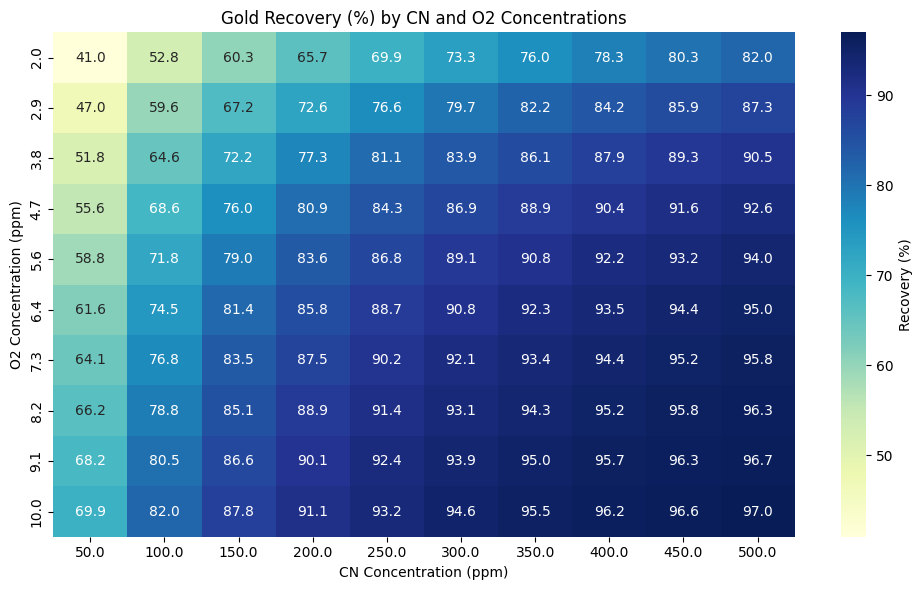

In [7]:
# Simulate recovery across CN and O2 values
cn_values = np.linspace(50, 500, 10)
o2_values = np.linspace(2, 10, 10)
results = []

for cn in cn_values:
	for o2 in o2_values:
		recovery = simulate_recovery_through_tanks(CN_ppm=cn, O2_ppm=o2, d=80,
				n_tanks=n_tanks, total_residence_time=(total_residence_time / n_tanks))
		results.append({"CN_ppm": cn, "O2_ppm": round(o2, 1), "Recovery": recovery * 100})

df_surface = pd.DataFrame(results)

# Pivot for heatmap
heatmap_data = df_surface.pivot(index="O2_ppm", columns="CN_ppm", values="Recovery")


# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "Recovery (%)"})
plt.title("Gold Recovery (%) by CN and O2 Concentrations")
plt.xlabel("CN Concentration (ppm)")
plt.ylabel("O2 Concentration (ppm)")
plt.tight_layout()
plt.show()

Random Row Parameters:
Feed Grade: 1.97 g/t
Cyanide Concentration: 375 ppm
Dissolved Oxygen: 20.50107142857143 ppm
Effective Particle Size: 87.2800158264401 µm



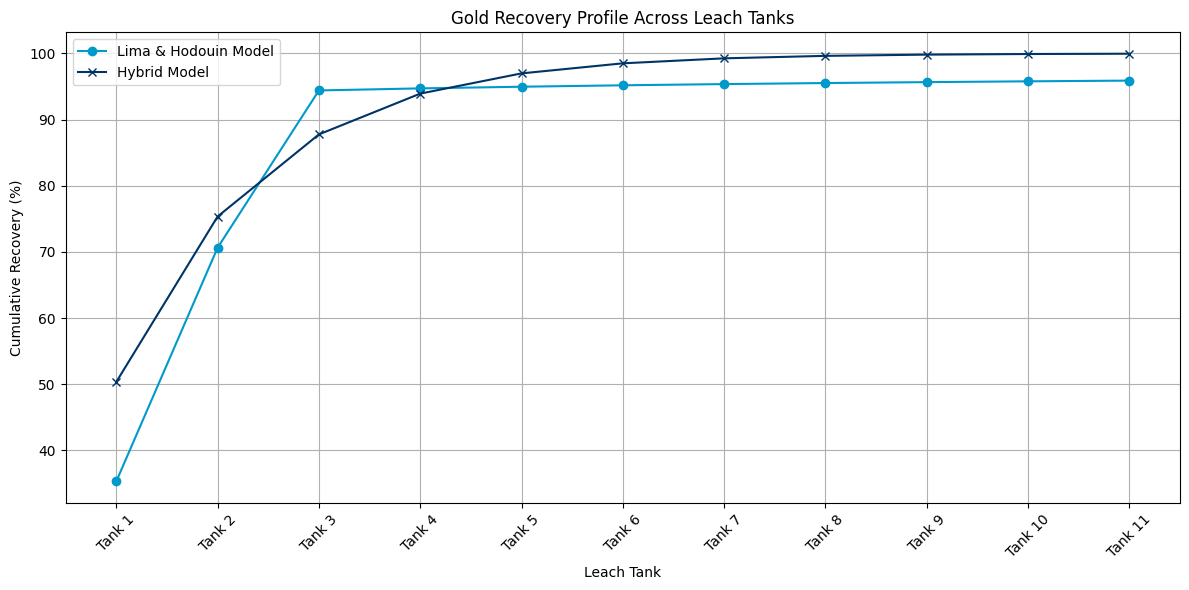

In [58]:
# Define Lima & Hodouin kinetic model
def lima_hodouin_dissolution(Au_s, Au_sl, CN, O2, d, k1=1.13e-3, k2=4.37e-11,
							  a=2.13, b=0.961, c=0.228, d_exp=2.93,
							  max_rate=0.25):
	"""Return rate in mg/kg/h"""
	k = k1 - k2 * d**d_exp
	if k <= 0 or CN <= 0 or O2 <= 0:
		return 0
	delta = max(Au_s - Au_sl, 0)
	rate = k * delta**a * CN**b * O2**c
	return np.clip(rate, 0, max_rate)


# Define hybrid exponential kinetic model
def hybrid_dissolution(d, t, au0, threshold=50, A=2.98e2, B=2.21,
					   f_fast=0.6, fast_mult=3.0, slow_mult=0.3):
	### TEMPORARY: Use a simplified model for demonstration
	A = 800   # higher base rate
	B = 1.8   # less aggressive penalty on d
	fast_mult = 4.0
	slow_mult = 0.6
	### END TEMPORARY
	k = A * d**(-B)
	if d <= threshold:
		k_fast = k * fast_mult
		k_slow = k * slow_mult
		return f_fast * au0 * np.exp(-k_fast * t) + (1 - f_fast) * au0 * np.exp(-k_slow * t)
	else:
		return au0 * np.exp(-k * t)


# Wrapper to simulate L&H recovery across tanks
def simulate_recovery_lh(feed_grade, CN, O2, d, n_tanks=n_tanks,
						 total_res_time=total_residence_time,
						 locked_gold_threshold=locked_gold_threshold):
	au_remaining = feed_grade * (1 - locked_gold_threshold)
	au_sl = feed_grade * locked_gold_threshold
	res_time_per_tank = total_res_time / n_tanks
	recovery_pct = []
	tank_details = []

	for _ in range(n_tanks):
		rate = lima_hodouin_dissolution(au_remaining, au_sl, CN, O2, d)
		delta = min(rate * res_time_per_tank, au_remaining)
		au_remaining = max(au_remaining - delta, au_sl)
		pct = (
			(feed_grade * (1 - locked_gold_threshold) - au_remaining) / 
			(feed_grade * (1 - locked_gold_threshold))
   		) * 100
		recovery_pct.append(pct)
		tank_details.append({
			"rate_g_kgh": rate,
			"delta_mgkg": delta,
			"remaining_Au": au_remaining,
			"dissolved_pct": pct
		})

	return recovery_pct, tank_details


# Wrapper to simulate Hybrid model recovery across tanks
def simulate_recovery_hybrid(feed_grade, d, n_tanks=n_tanks,
							 total_res_time=total_residence_time,
							 locked_gold_threshold=locked_gold_threshold):
	au_remaining = feed_grade * (1 - locked_gold_threshold)
	res_time_per_tank = total_res_time / n_tanks
	recovery_pct = []

	for _ in range(n_tanks):
		au_remaining = hybrid_dissolution(d, res_time_per_tank, au_remaining)
		pct = (feed_grade * (1 - locked_gold_threshold) - au_remaining) / (feed_grade * (1 - locked_gold_threshold)) * 100
		recovery_pct.append(pct)

	return recovery_pct


# Compute Weighted Particle Size per Row
def get_effective_particle_size(row):
	total = (
		row["Leach_Feed_Lt_75um_Day"] +
		row["Leach_Feed_Gt_75um_Day"] +
		row["Leach_Feed_Gt_150um_Day"]
	)
	if total == 0:
		return np.nan

	weighted_d = (
		row["Leach_Feed_Lt_75um_Day"] * ultra_fine_sizing +     
		row["Leach_Feed_Gt_75um_Day"] * fine_sizing +  			
		row["Leach_Feed_Gt_150um_Day"] * coarse_sizing     		
	) / total

	return weighted_d

df["Effective_Particle_Size_um"] = df.apply(get_effective_particle_size, axis=1)

# Select a random row from df
random_row = df.sample(n=1).iloc[0]

# Extract input parameters from the random row
feed_grade = random_row["Leach_Feed_Grade_Au_Gt_Day"]
CN = random_row["Leach_Cn_Adds_ppm"]
O2 = random_row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"]
d = random_row["Effective_Particle_Size_um"]

# Print the extracted parameters
print(f"Random Row Parameters:\n"
	  f"Feed Grade: {feed_grade} g/t\n"
	  f"Cyanide Concentration: {CN} ppm\n"
	  f"Dissolved Oxygen: {O2} ppm\n"
	  f"Effective Particle Size: {d} µm\n")

# Run both models on the random row
lh_recovery, lh_details = simulate_recovery_lh(
	feed_grade=feed_grade,
	CN=CN,
	O2=O2,
	d=d
)

hybrid_recovery = simulate_recovery_hybrid(
	feed_grade=feed_grade,
	d=d
)

# Return recovery per tank from both models
df_recovery = pd.DataFrame({
	"Tank": [f"Tank {i+1}" for i in range(11)],
	"Lima_Hodouin_Recovery_%": lh_recovery,
	"Hybrid_Recovery_%": hybrid_recovery
})


pf.plot_multiple_lines(
	df=df_recovery,
	x_col="Tank",
	y_series=[
		{"col": "Lima_Hodouin_Recovery_%", "label": "Lima & Hodouin Model", "style": {"marker": "o"}},
		{"col": "Hybrid_Recovery_%", "label": "Hybrid Model", "style": {"marker": "x"}}
	],
	title="Gold Recovery Profile Across Leach Tanks",
	x_label="Leach Tank",
	y_label="Cumulative Recovery (%)"
)


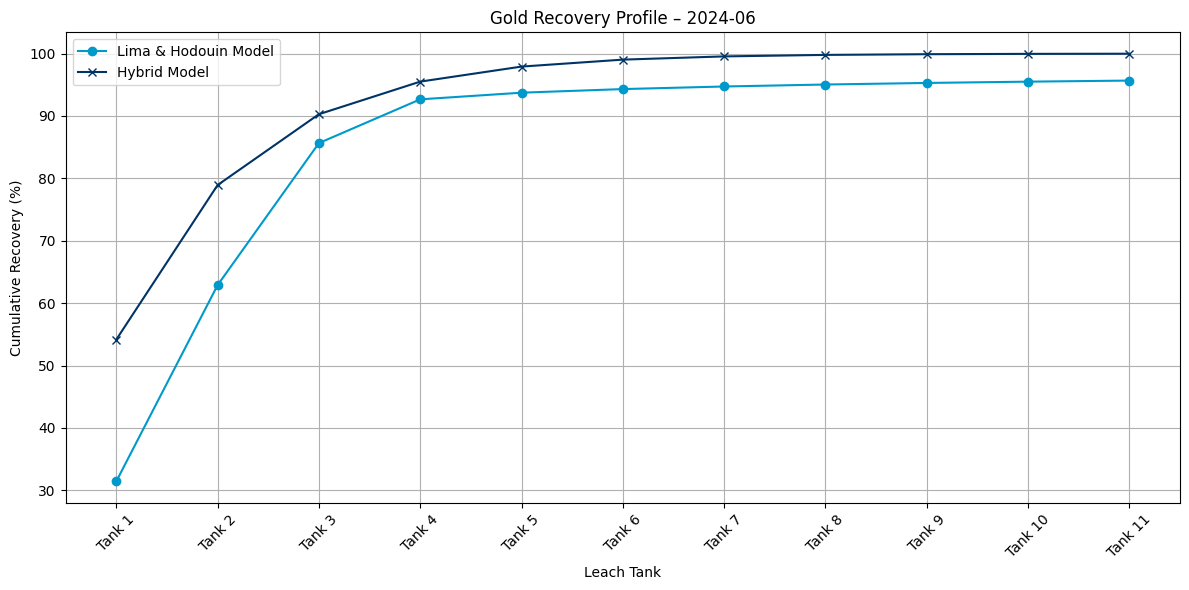

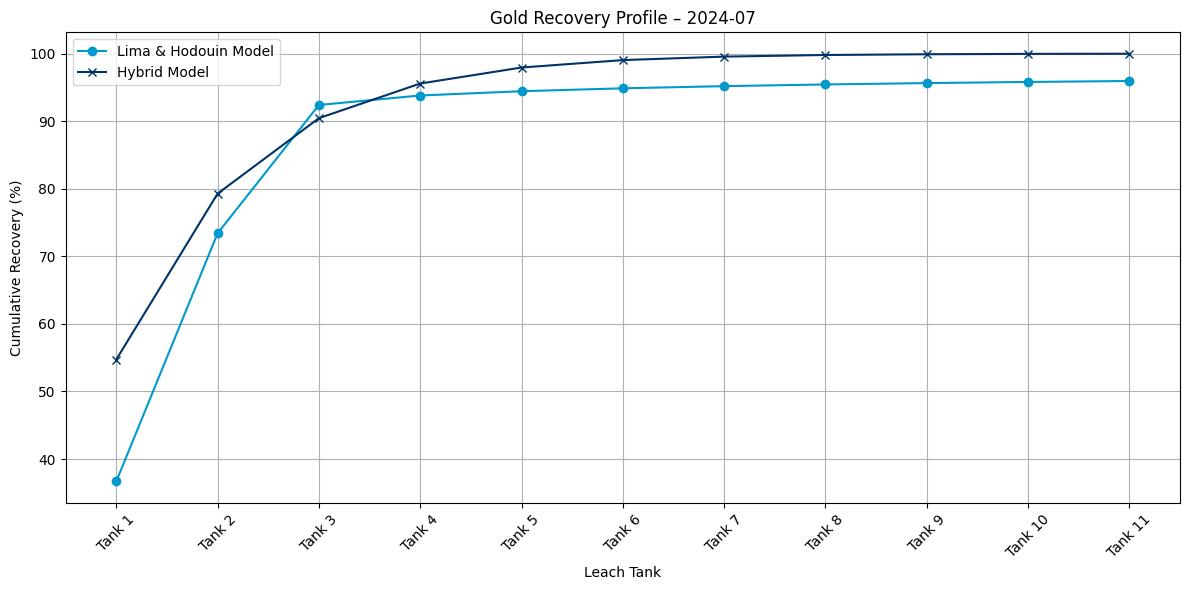

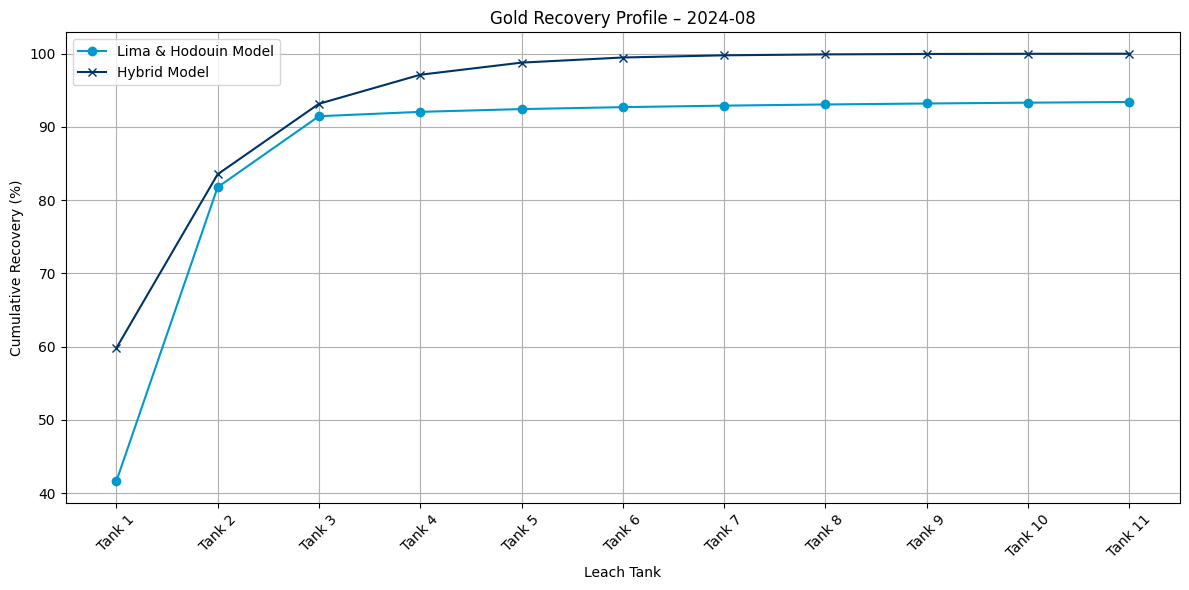

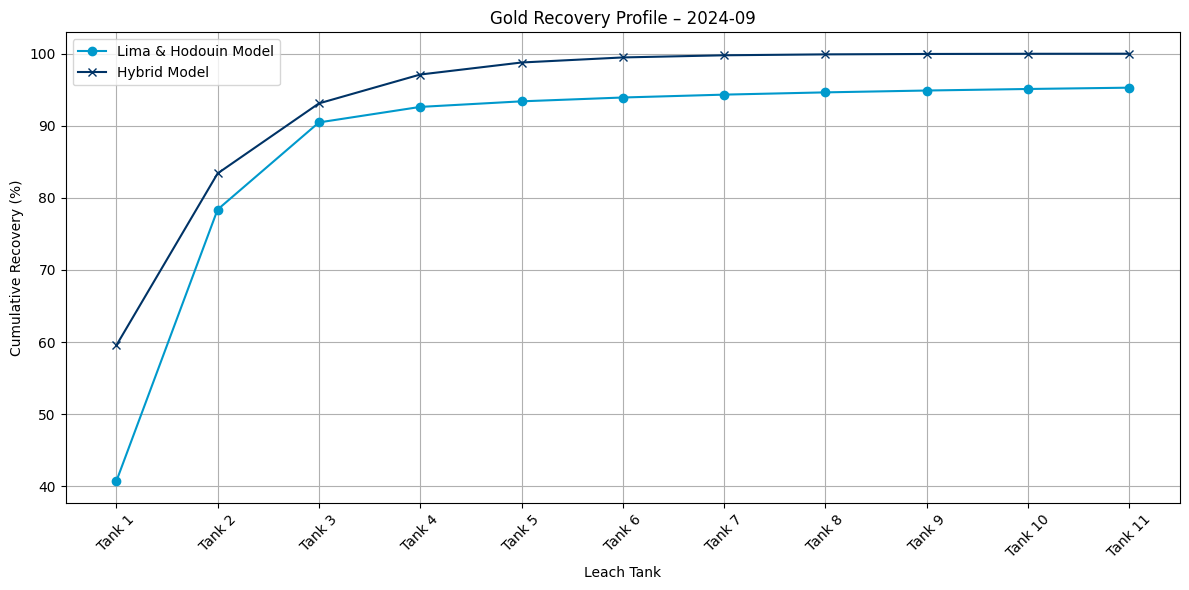

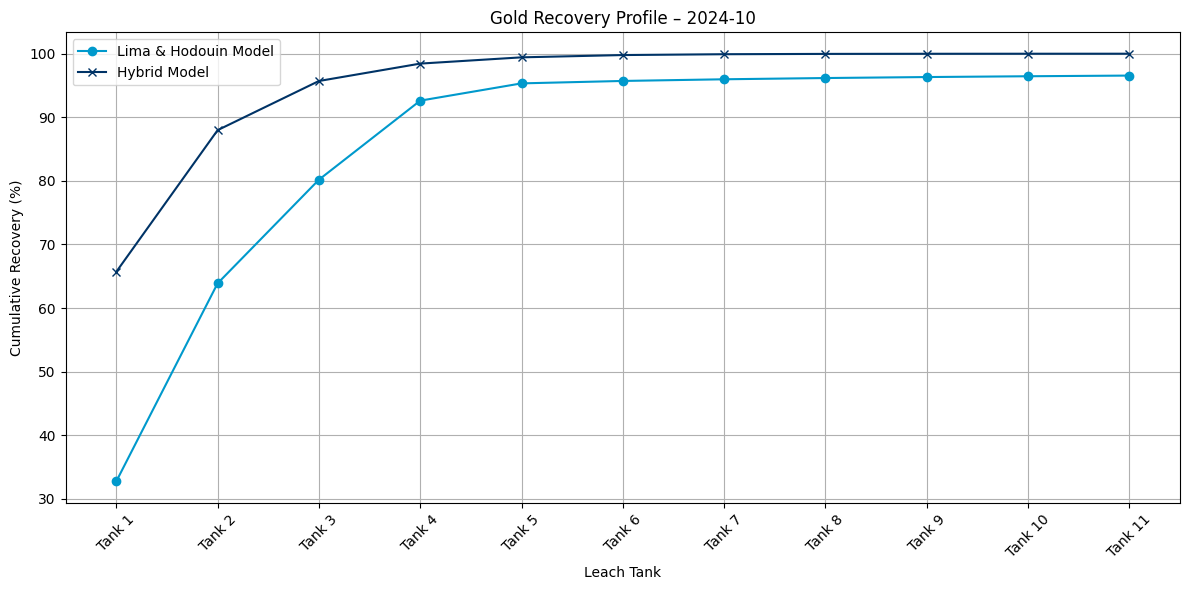

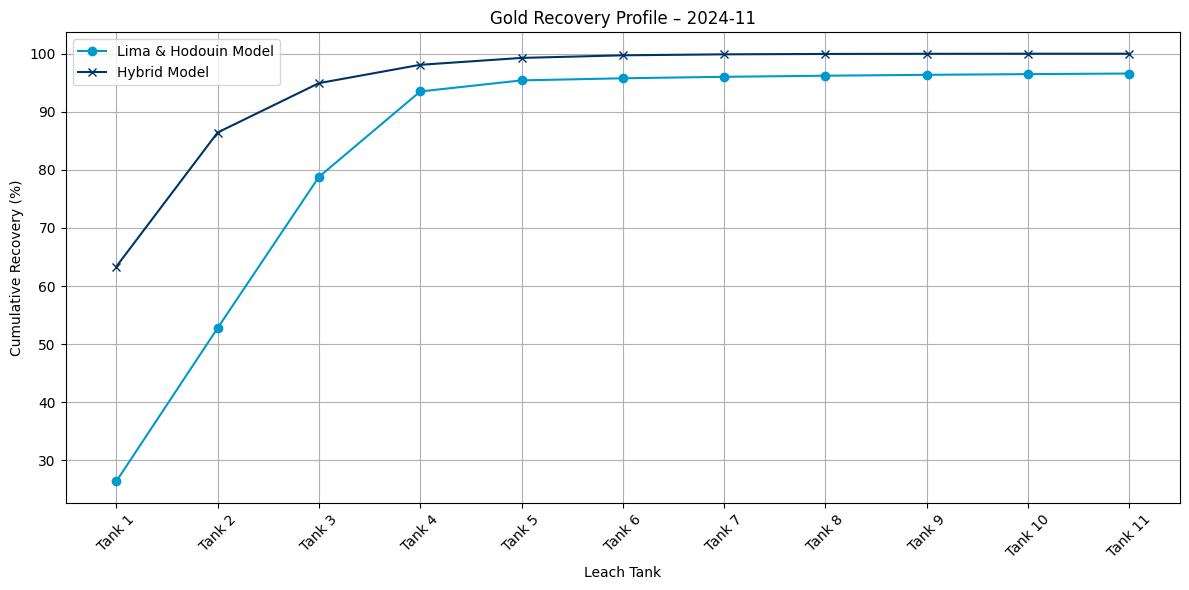

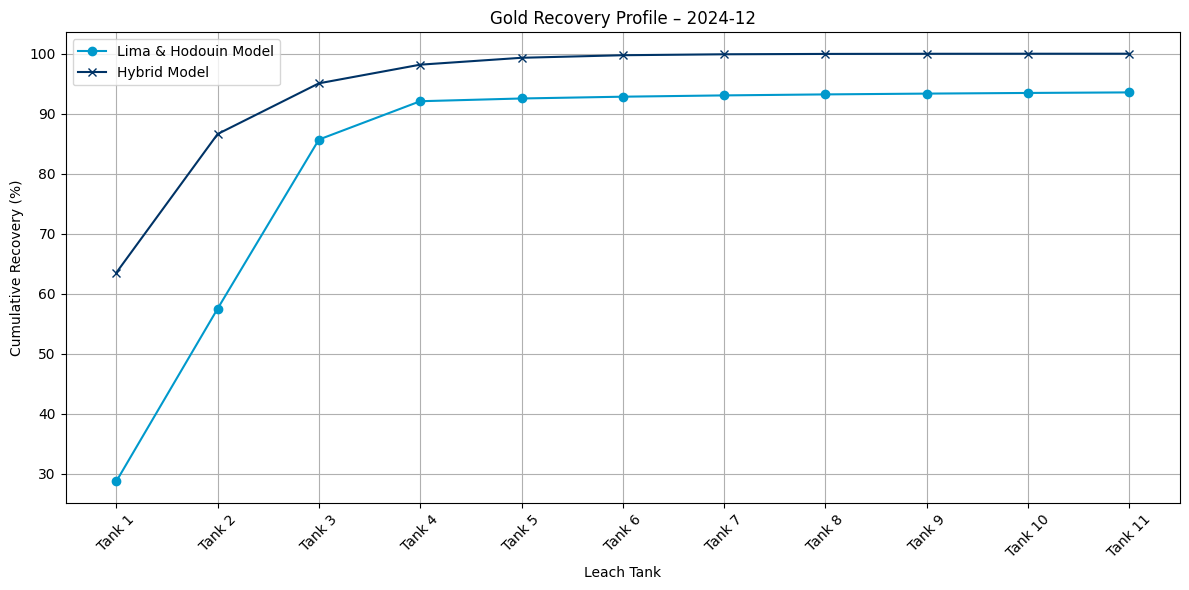

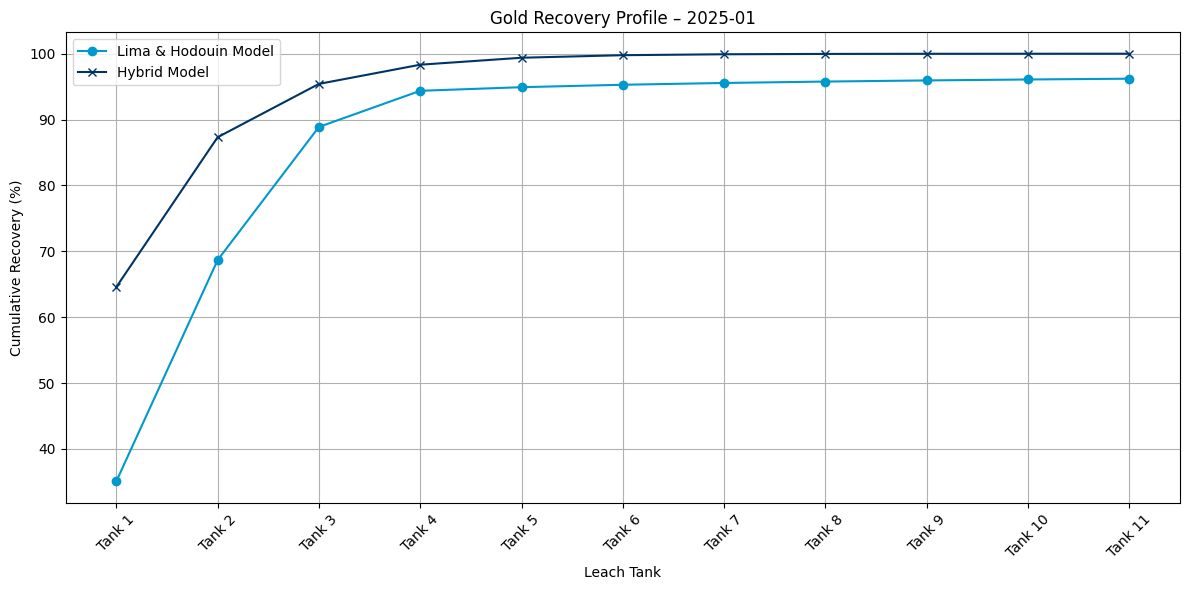

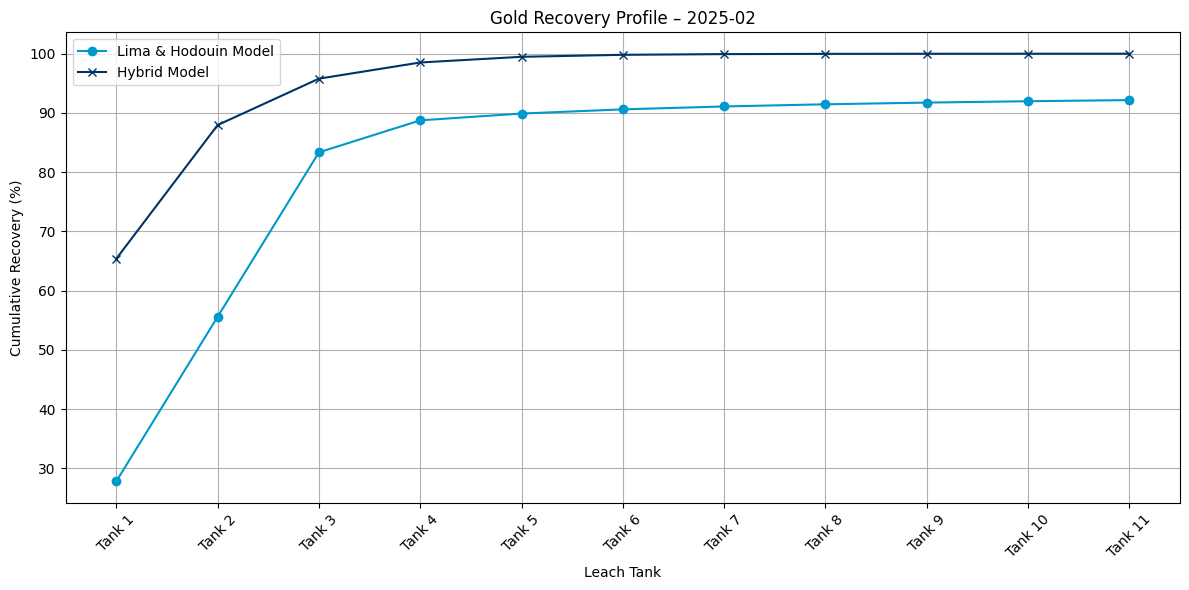

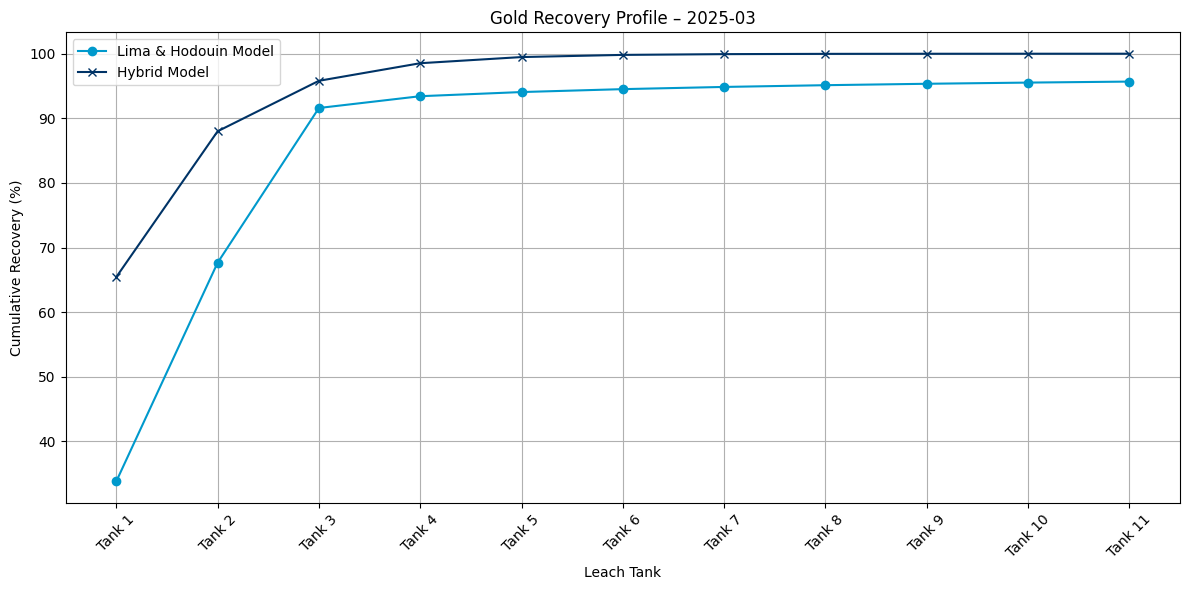

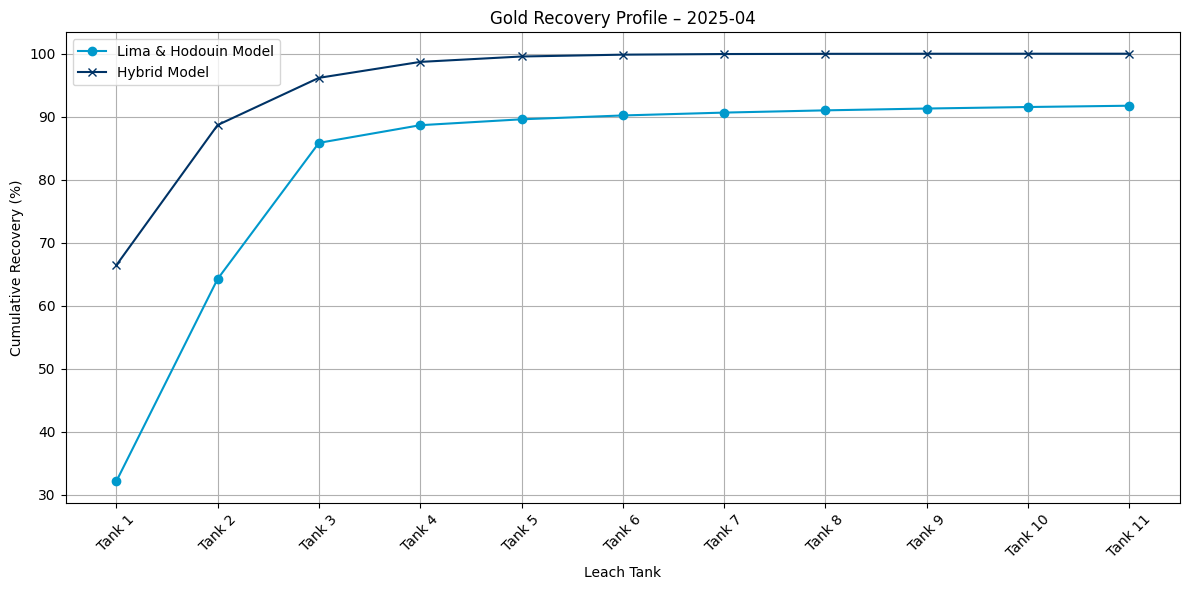

In [9]:
lh_features = [
	"Leach_Feed_Grade_Au_Gt_Day",
	"Leach_Cn_Adds_ppm",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth",
	"Effective_Particle_Size_um"
]

df_valid = df.dropna(subset=lh_features)

grouped = df_valid.groupby("Month")

for month, group in grouped:
	lh_matrix = []
	hybrid_matrix = []

	for _, row in group.iterrows():
		feed_grade = row["Leach_Feed_Grade_Au_Gt_Day"]
		CN = row["Leach_Cn_Adds_ppm"]
		O2 = row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"]
		d = row["Effective_Particle_Size_um"]

		try:
			lh_recovery, _ = simulate_recovery_lh(feed_grade, CN, O2, d)
			hybrid_recovery = simulate_recovery_hybrid(feed_grade, d)
			lh_matrix.append(lh_recovery)
			hybrid_matrix.append(hybrid_recovery)
		except Exception as e:
			print(f"Skipped row due to error: {e}")

	# Average across all rows in the month
	lh_avg = np.mean(lh_matrix, axis=0)
	hybrid_avg = np.mean(hybrid_matrix, axis=0)

	# Plot
	df_plot = pd.DataFrame({
		"Tank": [f"Tank {i+1}" for i in range(11)],
		"Lima_Hodouin_Recovery_%": lh_avg,
		"Hybrid_Recovery_%": hybrid_avg
	})

	pf.plot_multiple_lines(
		df=df_plot,
		x_col="Tank",
		y_series=[
			{"col": "Lima_Hodouin_Recovery_%", "label": "Lima & Hodouin Model", "style": {"marker": "o"}},
			{"col": "Hybrid_Recovery_%", "label": "Hybrid Model", "style": {"marker": "x"}}
		],
		title=f"Gold Recovery Profile – {month}",
		x_label="Leach Tank",
		y_label="Cumulative Recovery (%)"
	)


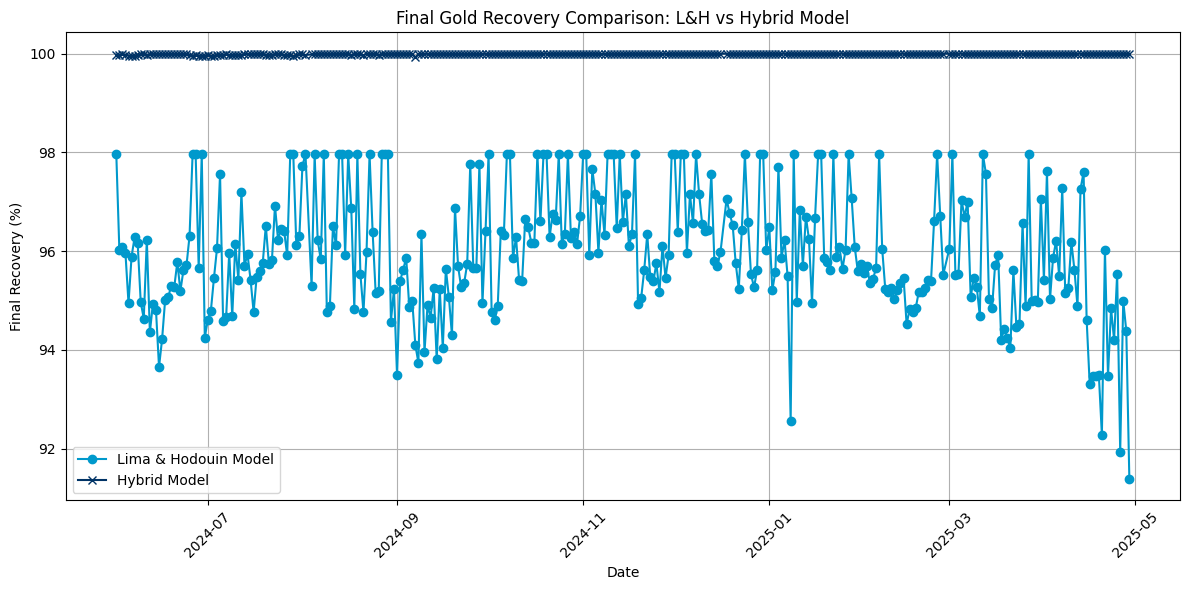

In [10]:
results = []
for _, row in df.dropna(subset=["Effective_Particle_Size_um", "Leach_Feed_Grade_Au_Gt_Day"]).iterrows():
	lh_pct, _ = simulate_recovery_lh(
		feed_grade=row["Leach_Feed_Grade_Au_Gt_Day"],
		CN=row["Leach_Cn_Adds_ppm"],
		O2=row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"],
		d=row["Effective_Particle_Size_um"]
	)
	hybrid_pct = simulate_recovery_hybrid(
		feed_grade=row["Leach_Feed_Grade_Au_Gt_Day"],
		d=row["Effective_Particle_Size_um"]
	)
	results.append({
		"Date": row["Date"],
		"LH_Final_Recovery": lh_pct[-1],
		"Hybrid_Final_Recovery": hybrid_pct[-1]
	})

df_results = pd.DataFrame(results)

# Drop rows with zero recoveries
df_results = df_results[
	(df_results["LH_Final_Recovery"] > 0) & (df_results["Hybrid_Final_Recovery"] > 0)
	]

pf.plot_multiple_lines(
	df=df_results,
	x_col="Date",
	y_series=[
		{"col": "LH_Final_Recovery", "label": "Lima & Hodouin Model", "style": {"marker": "o"}},
		{"col": "Hybrid_Final_Recovery", "label": "Hybrid Model", "style": {"marker": "x"}}
	],
	title="Final Gold Recovery Comparison: L&H vs Hybrid Model",
	x_label="Date",
	y_label="Final Recovery (%)"
)

## Inverse Solver
Estimate the cyanide concentration (CN ppm) required to achieve a target gold recovery, given:
* Feed grade (Au g/t),
* Dissolved oxygen (O₂ ppm),
* Effective particle size (d in µm),
* Number of leach tanks (fixed, e.g. 11),
* Residence time (e.g. 30 hours).

Uses a numerical root-finding method (e.g. Brent’s method or binary search),

Iteratively adjusts CN ppm to minimise the difference between simulated and target recovery using the Lima & Hodouin model.

In [11]:
# Recovery simulation using L&H model
def simulate_recovery_lh(feed_grade, CN, O2, d, n_tanks=n_tanks,
						 total_res_time=total_residence_time,
						 locked_gold_threshold=locked_gold_threshold):
	au_remaining = feed_grade * (1 - locked_gold_threshold)
	au_sl = feed_grade * locked_gold_threshold
	res_time_per_tank = total_res_time / n_tanks

	for _ in range(n_tanks):
		rate = lima_hodouin_dissolution(au_remaining, au_sl, CN, O2, d)
		delta = min(rate * res_time_per_tank, au_remaining)
		au_remaining = max(au_remaining - delta, au_sl)

	recovery_pct = (feed_grade * (1 - locked_gold_threshold) - au_remaining) / (feed_grade * (1 - locked_gold_threshold)) * 100
	return recovery_pct

# Inverse solver for required CN ppm
def solve_cn_for_target_recovery(feed_grade, O2, d, target_recovery,
								 cn_bounds=(10, 1000), tol=1e-2):
	def objective(cn):
		recovery = simulate_recovery_lh(feed_grade, cn, O2, d)
		return recovery - target_recovery

	try:
		cn_required = brentq(objective, cn_bounds[0], cn_bounds[1], xtol=tol)
		return cn_required
	except ValueError:
		return np.nan

# Sample cases
sample_cases = [
	{"feed_grade": 1.5, "O2": 8, "d": 80, "target_recovery": 90},
	{"feed_grade": 2.0, "O2": 8, "d": 80, "target_recovery": 92},
	{"feed_grade": 2.5, "O2": 8, "d": 80, "target_recovery": 94},
	{"feed_grade": 2.0, "O2": 6, "d": 80, "target_recovery": 92},
	{"feed_grade": 2.0, "O2": 10, "d": 80, "target_recovery": 92},
	{"feed_grade": 2.0, "O2": 8, "d": 100, "target_recovery": 92},
	{"feed_grade": 2.0, "O2": 8, "d": 50, "target_recovery": 92},
]

results = [
	{
		**case,
		"CN_required": solve_cn_for_target_recovery(**case)
	}
	for case in sample_cases
]

df_results = pd.DataFrame(results)
print("Inverse Solver Results")
print(df_results)


Inverse Solver Results
   feed_grade  O2    d  target_recovery  CN_required
0         1.5   8   80               90   176.266844
1         2.0   8   80               92   190.861865
2         2.5   8   80               94   252.801004
3         2.0   6   80               92   204.343733
4         2.0  10   80               92   181.020165
5         2.0   8  100               92   193.610072
6         2.0   8   50               92   188.690762


## Au Recovery Sensitivity to CN

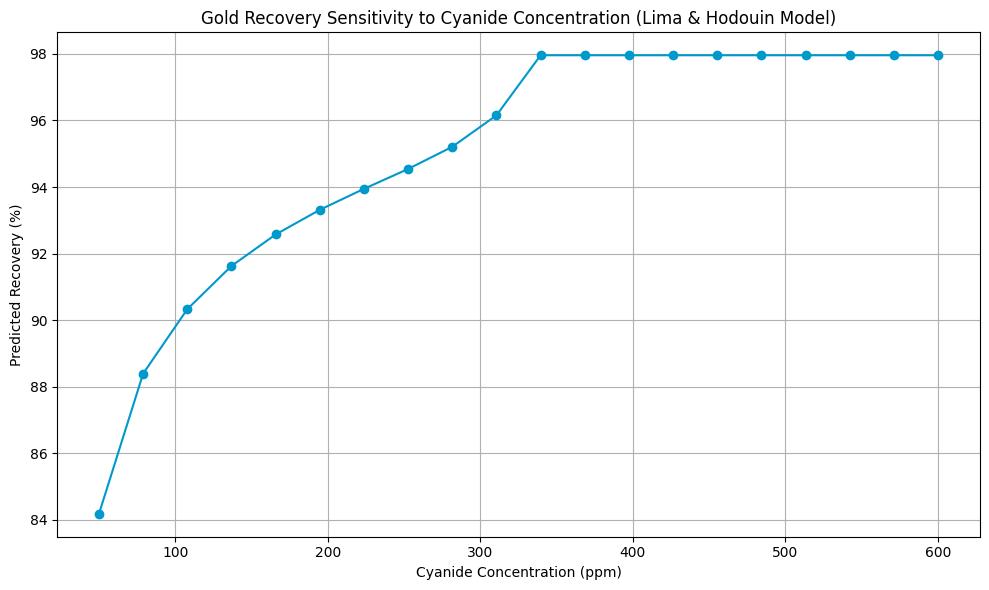

In [12]:
# Calculate gold recovery metrics
df["Au_Recovered_grams"] = (df["Cil_Feed_Total_Au_Grams"] - df["Total_Au_Tailing_Grams"])
df["Au_Recovered_grams"] = df["Au_Recovered_grams"].clip(0, df["Au_Recovered_grams"])
df["Au_Recovery_pct"] = df["Au_Recovered_grams"] / df["Cil_Feed_Total_Au_Grams"]

# Drop rows with missing inputs required for simulation
df = df.dropna(subset=[
	"Leach_Feed_Grade_Au_Gt_Day",
	"Leach_Cn_Adds_ppm",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed",
	"Effective_Particle_Size_um"
]).copy()

# Apply the simulation to each row
df["Modelled_Recovery_pct"] = df.apply(lambda row: simulate_recovery_lh(
	row["Leach_Feed_Grade_Au_Gt_Day"],
	row["Effective_Particle_Size_um"],
	row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed"],
	row["Leach_Cn_Adds_ppm"]
), axis=1) / 100


# Redefine the sensitivity simulation function for the Lima & Hodouin model
def simulate_lh_recovery_cn(feed_grade, d, O2, CN_values):
	results = []
	for CN in CN_values:
		au_remain = feed_grade * (1 - locked_gold_threshold)
		au_sl = feed_grade * locked_gold_threshold
		res_time = total_residence_time / 11
		for _ in range(11):
			rate = lima_hodouin_dissolution(au_remain, au_sl, CN, O2, d)
			delta = min(rate * res_time, au_remain)
			au_remain = max(au_remain - delta, au_sl)
		final_pct = ((feed_grade * (1 - locked_gold_threshold) - au_remain) / 
			(feed_grade * (1 - locked_gold_threshold)) * 100)
		results.append(final_pct)
	return results

# Select a valid sample row again with the corrected oxygen column
sample_row = df.dropna(subset=[
	"Leach_Feed_Grade_Au_Gt_Day",
	"Leach_Cn_Adds_ppm",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed",
	"Effective_Particle_Size_um"
]).iloc[0]

# Extract parameters
feed_grade = sample_row["Leach_Feed_Grade_Au_Gt_Day"]
d = sample_row["Effective_Particle_Size_um"]
O2_fixed = sample_row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed"]
CN_range = np.linspace(50, 600, 20)

# Now retry the simulation
recovery_results = simulate_lh_recovery_cn(feed_grade, d, O2_fixed, CN_range)

# Plot the sensitivity curve
pf.plot_single_line(
	x=CN_range,
	y=recovery_results,
	fig_size=(10, 6),
	title="Gold Recovery Sensitivity to Cyanide Concentration (Lima & Hodouin Model)",
	xlabel="Cyanide Concentration (ppm)",
	ylabel="Predicted Recovery (%)"
)


#### 🧠 Interpretation
The plot above shows how predicted gold recovery varies with cyanide concentration using the Lima & Hodouin kinetic model. As expected, recovery increases with higher CN levels, eventually tapering off as the system approaches saturation.

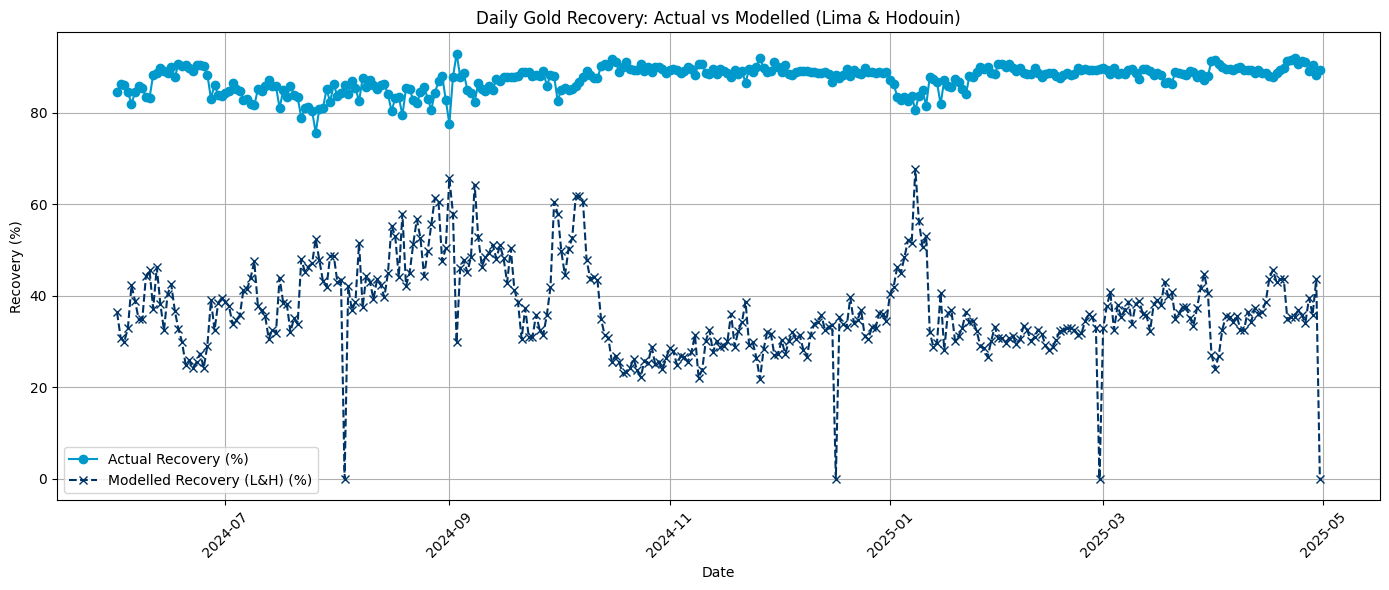

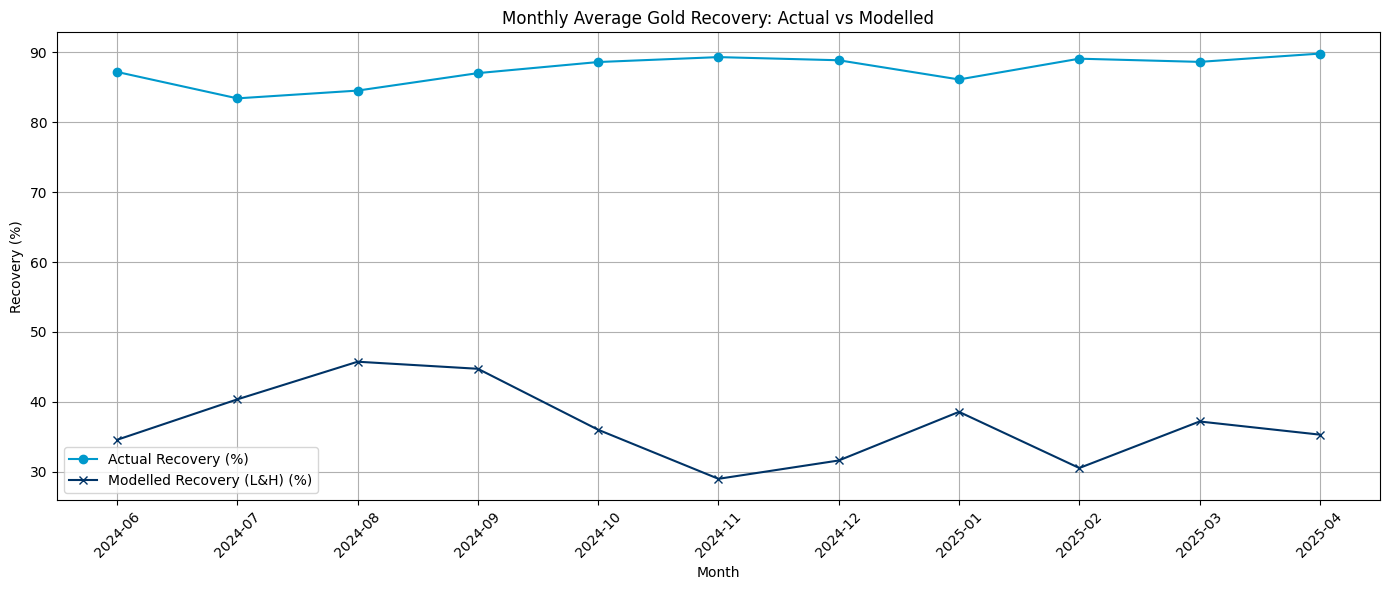

In [13]:
def simulate_lh_recovery(feed_grade, d, O2, CN):
	"""Simulates final recovery (%) using Lima & Hodouin model"""
	feed_grade_mg_per_kg = feed_grade * 1000  # convert g/t to mg/kg

	au_remain = feed_grade_mg_per_kg * (1 - locked_gold_threshold)
	au_sl = feed_grade_mg_per_kg * locked_gold_threshold
	res_time = total_residence_time / 11  # assuming 11 tanks

	for _ in range(11):
		rate = lima_hodouin_dissolution(au_remain, au_sl, CN, O2, d)  # mg/kg/h
		delta = min(rate * res_time, au_remain)
		au_remain = max(au_remain - delta, au_sl)

	recovered = feed_grade_mg_per_kg * (1 - locked_gold_threshold) - au_remain
	final_pct = (recovered / (feed_grade_mg_per_kg * (1 - locked_gold_threshold))) * 100
	return final_pct


# Drop rows with missing inputs required for simulation
df_valid = df.dropna(subset=[
	"Leach_Feed_Grade_Au_Gt_Day",
	"Leach_Cn_Adds_ppm",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed",
	"Effective_Particle_Size_um"
]).copy()

# Apply the simulation to each row
df_valid["Modelled_Recovery_pct"] = df_valid.apply(lambda row: simulate_lh_recovery(
	row["Leach_Feed_Grade_Au_Gt_Day"],
	row["Effective_Particle_Size_um"],
	row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed"],
	row["Leach_Cn_Adds_ppm"]
), axis=1)



# Plot 1: Daily Actual vs Modelled Recovery
pf.plot_multiple_lines(
	df=df_valid,
	x_col="Date",
	y_series=[
		{"col": "Au_Recovery_pct", "label": "Actual Recovery (%)", "style": {"marker": "o", "linestyle": "-"}},
		{"col": "Modelled_Recovery_pct", "label": "Modelled Recovery (L&H) (%)", "style": {"marker": "x", "linestyle": "--"}}
	],
	fig_size=(14, 6),
	title="Daily Gold Recovery: Actual vs Modelled (Lima & Hodouin)",
	x_label="Date",
	y_label="Recovery (%)",
	scale_y = 100
)

# Plot 2: Monthly Average Recovery Comparison
df_valid["Month"] = df_valid["Date"].dt.to_period("M")
monthly_avg = df_valid.groupby("Month")[["Au_Recovery_pct", "Modelled_Recovery_pct"]].mean().reset_index()
monthly_avg["Month"] = monthly_avg["Month"].astype(str)

pf.plot_multiple_lines(
	df = monthly_avg,
	x_col = "Month",
	y_series = [
		{"col": "Au_Recovery_pct", "label": "Actual Recovery (%)", "style": {"marker": "o"}},
		{"col": "Modelled_Recovery_pct", "label": "Modelled Recovery (L&H) (%)", "style": {"marker": "x"}}
	],
	fig_size = (14, 6),
	title = "Monthly Average Gold Recovery: Actual vs Modelled",
	x_label = "Month",
	y_label = "Recovery (%)",
	x_ticks_rotation = 45,
	scale_y = 100
)

### 📊 Residual and Error Analysis

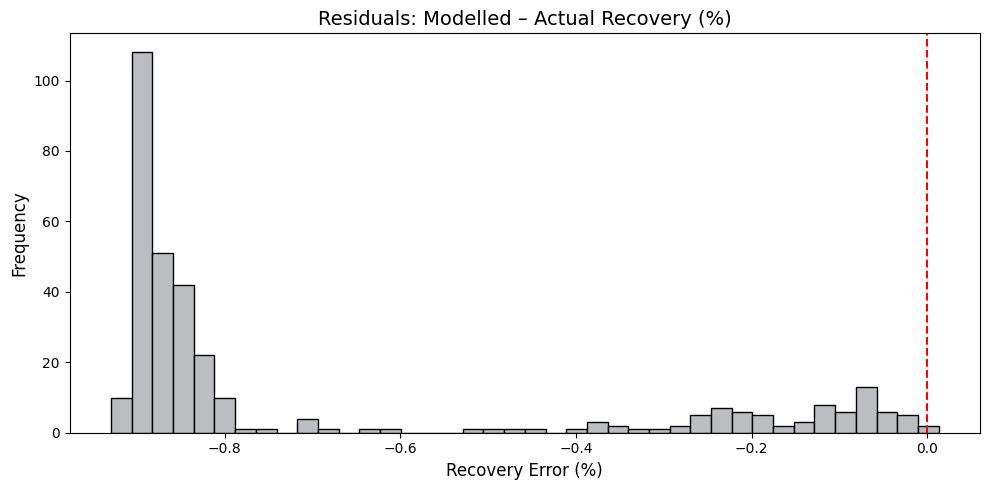

In [14]:
df["Recovery_Residual"] = df["Modelled_Recovery_pct"] - df["Au_Recovery_pct"]

pf.plot_histogram(
    data=df["Recovery_Residual"],
    title="Residuals: Modelled – Actual Recovery (%)",
    xlabel="Recovery Error (%)",
    ylabel="Frequency"
)

### Fit L&H Kinetics to Site Data
🧩 Step 1: Prepare the objective function

This function will:
* Take a set of kinetic parameters,
* Apply your L&H simulation across the dataset,
* Return the RMSE between modelled and actual recovery (to minimise).

In [15]:
max_rate = max_dissolution_rate

def objective_lh(params, df):
	k1, k2, a, b, c, d_exp = params

	def simulate_row(row):
		try:
			feed_grade = row["Leach_Feed_Grade_Au_Gt_Day"] * 1000  # g/t → mg/kg
			d = row["Effective_Particle_Size_um"]
			O2 = row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed"]
			CN = row["Leach_Cn_Adds_ppm"]
			au_remain = feed_grade * (1 - locked_gold_threshold)
			au_sl = feed_grade * locked_gold_threshold
			res_time = total_residence_time / 11

			for _ in range(11):
				k = k1 - k2 * d**d_exp
				rate = k * max(au_remain - au_sl, 0)**a * CN**b * O2**c
				rate = np.clip(rate, 0, max_rate)
				delta = min(rate * res_time, au_remain)
				au_remain = max(au_remain - delta, au_sl)

			recovered = feed_grade * (1 - locked_gold_threshold) - au_remain
			return recovered / (feed_grade * (1 - locked_gold_threshold)) * 100
		except:
			return np.nan

	df["Modelled_LH_Fit"] = df.apply(simulate_row, axis=1)
	df_clean = df.dropna(subset=["Modelled_LH_Fit", "Au_Recovery_pct"])

	return root_mean_squared_error(df_clean["Au_Recovery_pct"],
								df_clean["Modelled_LH_Fit"])


### Run optimisation
Use scipy.optimize.minimize with reasonable starting values and bounds.

In [16]:
initial_params = [1.13e-3, 4.37e-11, 2.13, 0.961, 0.228, 2.93]  # [k1, k2, a, b, c, d_exp]
bounds = [
	(1e-5, 1e-2),     # k1
	(1e-15, 1e-8),    # k2
	(0.1, 4),         # a
	(0.1, 2),         # b
	(0.1, 2),         # c
	(0.5, 5)          # d_exp
]

result = minimize(objective_lh, initial_params, args=(df.copy(),), method='L-BFGS-B', bounds=bounds)

best_params = result.x
print("Optimised Parameters:", best_params)

k1_fit, k2_fit, a_fit, b_fit, c_fit, d_exp_fit = best_params

Optimised Parameters: [1.13e-03 4.37e-11 2.13e+00 9.61e-01 2.28e-01 2.93e+00]


In [17]:
print("The parameters for the Lima & Hodouin model are:")
print(f"k1: {k1_fit:.2e}, k2: {k2_fit:.2e}, a: {a_fit:.2f}, b: {b_fit:.2f}, c: {c_fit:.2f}, d_exp: {d_exp_fit:.2f}")

The parameters for the Lima & Hodouin model are:
k1: 1.13e-03, k2: 4.37e-11, a: 2.13, b: 0.96, c: 0.23, d_exp: 2.93


### Optimised Parameters in Your Model

### Apply across your DataFrame

In [18]:
df["Modelled_Recovery_LH_Fitted"] = df.apply(lambda row: simulate_lh_recovery_fitted(
	row["Leach_Feed_Grade_Au_Gt_Day"],
	row["Effective_Particle_Size_um"],
	row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed"],
	row["Leach_Cn_Adds_ppm"],
	n_tanks, locked_gold_threshold, total_residence_time,
	best_params[0], best_params[1], best_params[2], best_params[3], best_params[4], best_params[5],
	max_dissolution_rate
), axis=1)


### Replot residuals

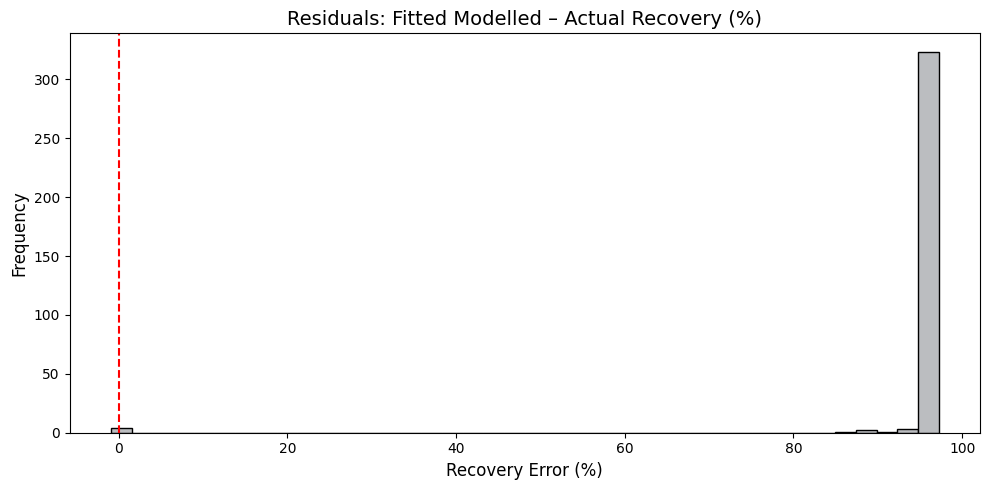

In [19]:
df["Recovery_Residual_Fitted"] = df["Modelled_Recovery_LH_Fitted"] - df["Au_Recovery_pct"]

pf.plot_histogram(
    data=df["Recovery_Residual_Fitted"],
    bins=40,
    title="Residuals: Fitted Modelled – Actual Recovery (%)",
    xlabel="Recovery Error (%)",
    ylabel="Frequency",
)


### Apply a Post-Fit Linear Correction

Calibrated Model: Recovery = 0.89 + -0.00 × L&H Output


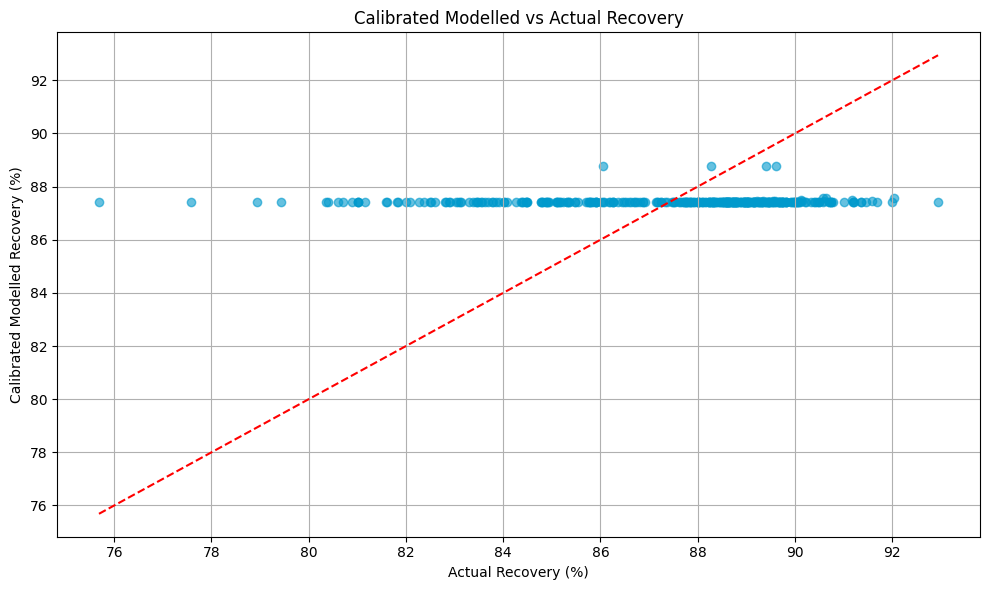

In [20]:
# Drop NaNs
df_fit = df.dropna(subset=["Modelled_Recovery_LH_Fitted", "Au_Recovery_pct"])

X = df_fit[["Modelled_Recovery_LH_Fitted"]]
y = df_fit["Au_Recovery_pct"]

# Fit linear correction
model_correction = LinearRegression()
model_correction.fit(X, y)

alpha = model_correction.intercept_
beta = model_correction.coef_[0]

print(f"Calibrated Model: Recovery = {alpha:.2f} + {beta:.2f} × L&H Output")

df["Recovery_Calibrated"] = alpha + beta * df["Modelled_Recovery_LH_Fitted"]

recovery_pct = df["Au_Recovery_pct"] * 100
calibrated_recovery_pct = df["Recovery_Calibrated"] * 100

pf.plot_actual_vs_predicted_scatter(
	y_actual=recovery_pct,
	y_pred=calibrated_recovery_pct,
    fig_size=(10, 6),
	title="Calibrated Modelled vs Actual Recovery",
	xlabel="Actual Recovery (%)",
	ylabel="Calibrated Modelled Recovery (%)",
    round_axes=True
)

In [21]:
print("L&H Modelled Recovery Stats:")
print(df["Modelled_Recovery_LH_Fitted"].describe())

print("Actual Recovery Stats:")
print(df["Au_Recovery_pct"].describe())

L&H Modelled Recovery Stats:
count    334.000000
mean      96.626158
std       10.705885
min        0.000000
25%       97.959184
50%       97.959184
75%       97.959184
max       97.959184
Name: Modelled_Recovery_LH_Fitted, dtype: float64
Actual Recovery Stats:
count    334.000000
mean       0.874508
std        0.027876
min        0.756872
25%        0.857884
50%        0.884245
75%        0.893365
max        0.929443
Name: Au_Recovery_pct, dtype: float64


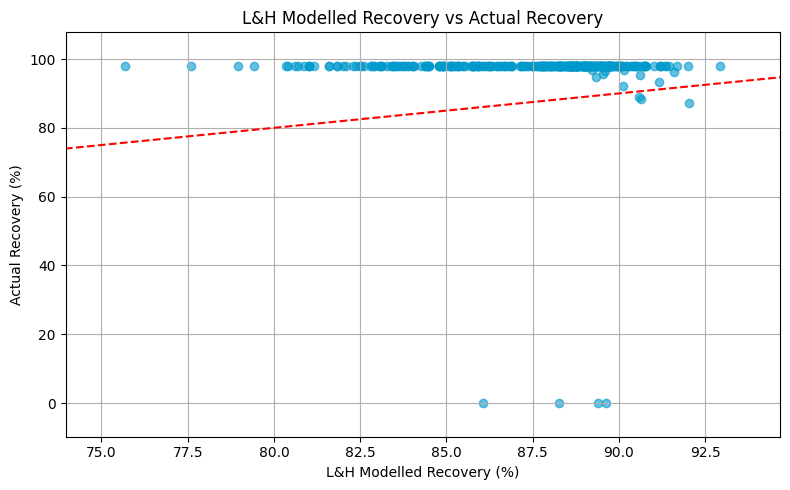

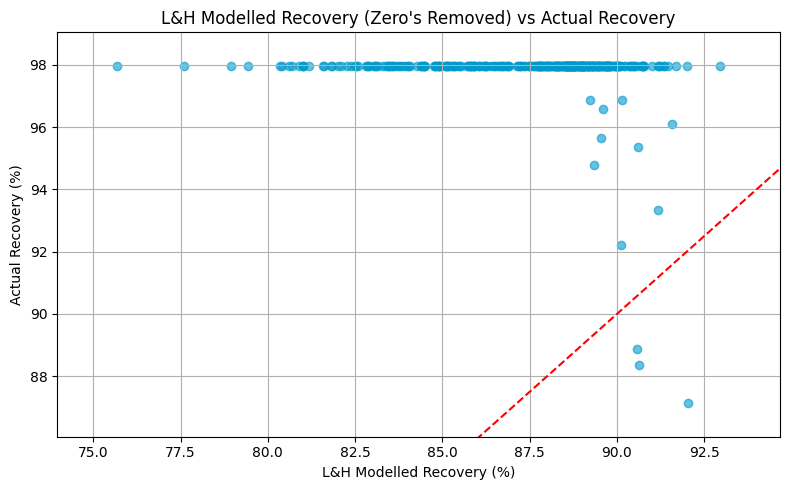

In [22]:
pf.plot_actual_vs_predicted_scatter(
	y_actual=recovery_pct,
	y_pred=df["Modelled_Recovery_LH_Fitted"],
	title="L&H Modelled Recovery vs Actual Recovery",
	xlabel="L&H Modelled Recovery (%)",
	ylabel="Actual Recovery (%)",
	fig_size=(8, 5),
	autoscale_x=True,
	autoscale_y=True,
)

# Filter rows where Modelled_Recovery_LH_Fitted > 0
df_filtered = df[df["Modelled_Recovery_LH_Fitted"] > 0].copy()

# Prepare scaled series from the filtered DataFrame
recovery_pct_no_zeros = df_filtered["Au_Recovery_pct"] * 100
modelled_recovery_pct = df_filtered["Modelled_Recovery_LH_Fitted"]

# Plot
pf.plot_actual_vs_predicted_scatter(
	y_actual=recovery_pct_no_zeros,
	y_pred=modelled_recovery_pct,
	title="L&H Modelled Recovery (Zero's Removed) vs Actual Recovery",
	xlabel="L&H Modelled Recovery (%)",
	ylabel="Actual Recovery (%)",
	fig_size=(8, 5),
	autoscale_x=True,
	autoscale_y=True
)


## Define features

In [23]:
features = [
	"Leach_Feed_Grade_Au_Gt_Day",
	"Leach_Cn_Adds_ppm",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed",
	"Effective_Particle_Size_um",
	"Modelled_Recovery_LH_Fitted"
]

### Fit a Random Forest (or XGBoost) regressor

R²: 0.5774
RMSE: 0.0201


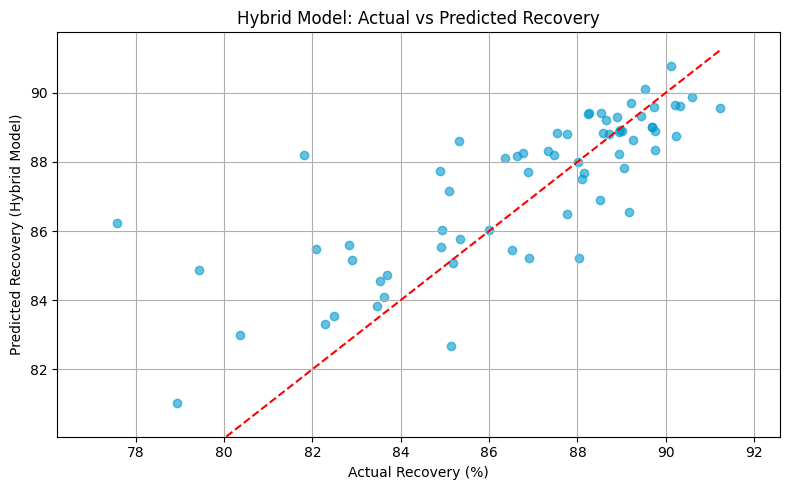

In [24]:
# Drop missing values
df_model = df.dropna(subset=features + ["Au_Recovery_pct"])
X = df_model[features]
y = df_model["Au_Recovery_pct"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
													random_state=random_seed)

# Fit model
model = RandomForestRegressor(n_estimators=100, random_state=random_seed)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")

pf.plot_actual_vs_predicted_scatter(
	y_actual=y_test * 100,
	y_pred=y_pred * 100,
	title="Hybrid Model: Actual vs Predicted Recovery",
	xlabel="Actual Recovery (%)",
	ylabel="Predicted Recovery (Hybrid Model)",
	fig_size=(8, 5),
	autoscale_x=True,
	autoscale_y=True
)

### Hybrid Model Performance Summary
* R² = 0.58: The model explains 58% of the variance in actual recovery — reasonable given noisy process data and absence of adsorption-specific features (e.g. carbon activity).
* RMSE = 2.00%: Prediction error is tight, well within operational tolerance.
* Visual Match: The scatter plot closely follows the 1:1 line, indicating well-calibrated and generalisable predictions.

### 🧠 What This Tells Us
* Mechanistic + ML hybridisation works — the Lima & Hodouin output, while weak on its own, adds signal when combined with CN, O₂, PSD, and feed grade.
* You can now trust the model to simulate recovery under different input scenarios (e.g. CN dose variation).
* Next-level accuracy would require adsorption dynamics (carbon inventory, fouling, residence time per tank, tailings assays).

### Feature Importance

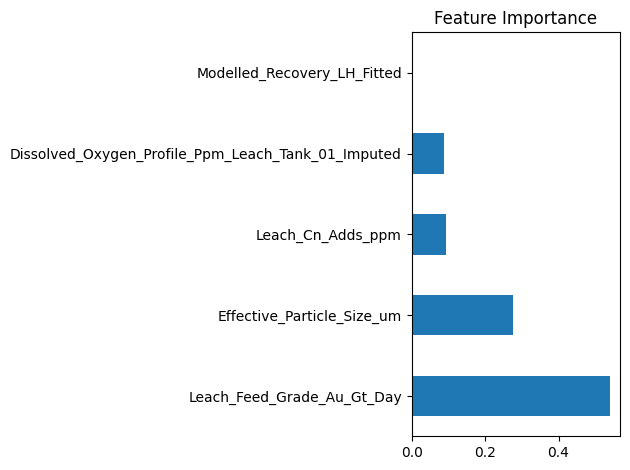

In [25]:
importances = model.feature_importances_
feature_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)
feature_importance.plot(kind='barh', title='Feature Importance')
plt.tight_layout()
plt.show()

### Create a Scenario Simulator Function
This function simulates recovery while varying one or two inputs (e.g. CN and O₂), holding others constant.

In [26]:
def simulate_hybrid_sensitivity(model, base_row, var_name, var_range):
	"""Simulate hybrid model response by varying a single input feature"""
	scenarios = []
	for val in var_range:
		row = base_row.copy()
		row[var_name] = val

		# Optionally recompute L&H model output if needed
		if var_name in ["Leach_Feed_Grade_Au_Gt_Day", "Effective_Particle_Size_um", "Leach_Cn_Adds_ppm", "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed"]:
			row["Modelled_Recovery_LH_Fitted"] = simulate_lh_recovery_fitted(
				row["Leach_Feed_Grade_Au_Gt_Day"],
				row["Effective_Particle_Size_um"],
				row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed"],
				row["Leach_Cn_Adds_ppm"],
				n_tanks, locked_gold_threshold,
				total_residence_time,
				k1_fit, k2_fit, a_fit, b_fit, c_fit, d_exp_fit,
				max_dissolution_rate
			)

		recovery = model.predict(pd.DataFrame([row]))[0]
		scenarios.append({"Value": val, "Predicted_Recovery": recovery})
	return pd.DataFrame(scenarios)

### 💻 Pick a representative base case

In [27]:
base_row = df.dropna(subset=features).iloc[0][features].copy()
print("Base Row for Sensitivity Analysis:")
print(base_row)

print(f"\nActual Recovery: {df.iloc[0]['Au_Recovery_pct'] * 100:.2f}%")

Base Row for Sensitivity Analysis:
Leach_Feed_Grade_Au_Gt_Day                                2.105
Leach_Cn_Adds_ppm                                           485
Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed        19.11
Effective_Particle_Size_um                            82.193626
Modelled_Recovery_LH_Fitted                           97.959184
Name: 0, dtype: object

Actual Recovery: 84.49%


### 📊 Run CN sensitivity

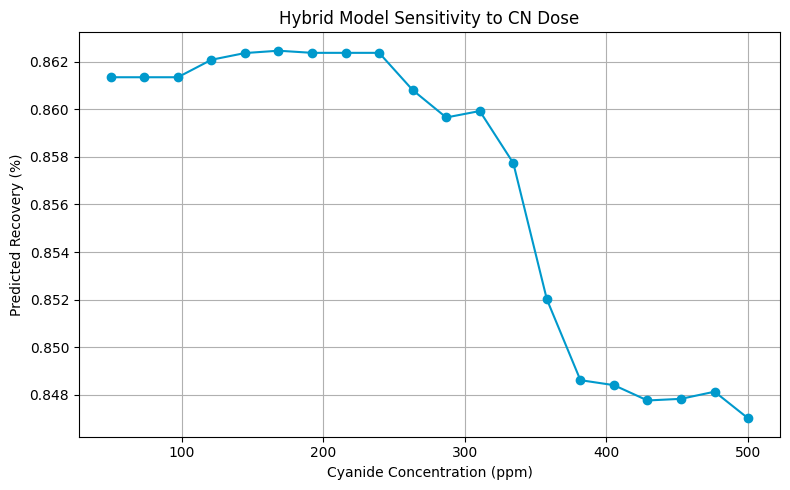

In [28]:
cn_range = np.linspace(50, 500, 20)
df_cn_sens = simulate_hybrid_sensitivity(model, base_row, "Leach_Cn_Adds_ppm", cn_range)

pf.plot_single_line(
	x=df_cn_sens["Value"],
	y=df_cn_sens["Predicted_Recovery"],
	fig_size=(8, 5),
	title="Hybrid Model Sensitivity to CN Dose",
	xlabel="Cyanide Concentration (ppm)",
	ylabel="Predicted Recovery (%)",
	marker="o",
)


### 💻 Correlation Matrix

In [29]:
df[features + ["Au_Recovery_pct"]].corr()["Au_Recovery_pct"].sort_values(ascending=False)

Au_Recovery_pct                                       1.000000
Leach_Feed_Grade_Au_Gt_Day                            0.665937
Modelled_Recovery_LH_Fitted                          -0.052600
Leach_Cn_Adds_ppm                                    -0.190286
Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed   -0.246392
Effective_Particle_Size_um                           -0.482986
Name: Au_Recovery_pct, dtype: float64

| Feature                       | Correlation with Recovery     |
| ----------------------------- | ----------------------------- |
| `Leach_Feed_Grade_Au_Gt_Day`  | **+0.67** (strong positive) ✅ |
| `Effective_Particle_Size_um`  | **–0.48** (finer → better) ✅  |
| `Modelled_Recovery_LH_Fitted` | **–0.05** (negligible)❌                   |
| `Leach_Cn_Adds_ppm`           | **–0.19** ❌                   |
| `Dissolved_Oxygen…`           | **–0.25** ❌                   |

### 🧠 Interpretation:
Strong inverse correlation of CN and O₂ with recovery persists — likely due to operational compensation, e.g. more CN or air added when recovery is low.
However, `Modelled_Recovery_LH_Fitted` now shows negligible correlation with actual recovery.
This may suggest:
* A model misfit, or
* Recovery being dominated by other latent variables not captured in the model inputs.

### 📊 SHAP for local interpretation
SHAP (SHapley Additive exPlanations) gives much clearer insight into what the model is doing:

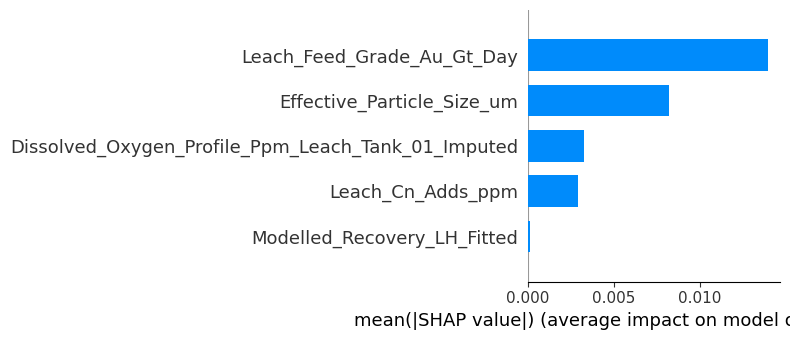

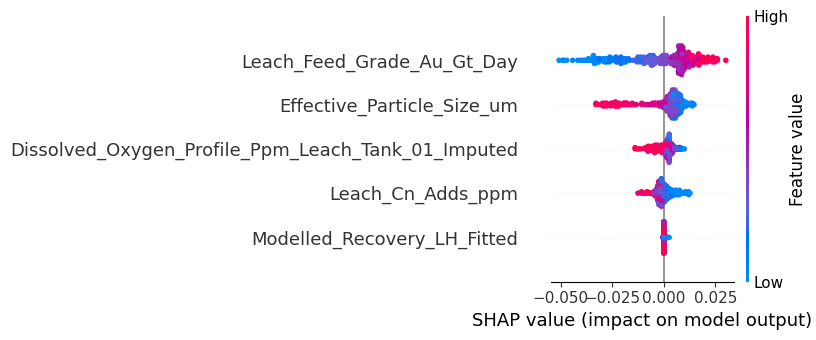

In [30]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X, plot_type="bar")   # global
shap.summary_plot(shap_values, X)                    # beeswarm

### SHAP Summary
* `Leach_Feed_Grade_Au_Gt_Day` is the most influential feature in model predictions - higher values strongly drive higher recovery.
* `Effective_Particle_Size_um` also plays a key role - finer particles (low values, in blue) are associated with better modelled recovery.
* High CN and O₂ values (red) generally reduce predicted recovery, suggesting the model still picks up false inverse patterns (likely due to operational compensation).
* `Modelled_Recovery_LH_Fitted` has minimal influence in the final model, despite being intended as a mechanistic reference.

### Engineer Derived Features with Domain Context

In [31]:
df["CN_per_grade"] = df["Leach_Cn_Adds_ppm"] / df["Leach_Feed_Grade_Au_Gt_Day"]
df["PSD_grade_ratio"] = df["Effective_Particle_Size_um"] / df["Leach_Feed_Grade_Au_Gt_Day"]
df["O2_to_CN"] = (df["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed"] / 
				  df["Leach_Cn_Adds_ppm"])
df["Recovery_gap"] = df["Au_Recovery_pct"] - df["Modelled_Recovery_LH_Fitted"]

extended_features = [
	"Leach_Feed_Grade_Au_Gt_Day",
	"Leach_Cn_Adds_ppm",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed",
	"Effective_Particle_Size_um",
	"Modelled_Recovery_LH_Fitted",
	"CN_per_grade",
	"PSD_grade_ratio",
	"O2_to_CN"
]

# Check for infinite or NaN values
invalid_rows = df[extended_features].replace([np.inf, -np.inf], np.nan).isna().sum()
print("Missing or invalid value counts:")
print(invalid_rows.sort_values(ascending=False))

Missing or invalid value counts:
O2_to_CN                                              4
Leach_Feed_Grade_Au_Gt_Day                            0
Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed    0
Leach_Cn_Adds_ppm                                     0
Effective_Particle_Size_um                            0
Modelled_Recovery_LH_Fitted                           0
CN_per_grade                                          0
PSD_grade_ratio                                       0
dtype: int64


## Retrain with additional features

Rows before cleaning: 334
Rows after cleaning: 330
R²: 0.6491
RMSE: 0.0177


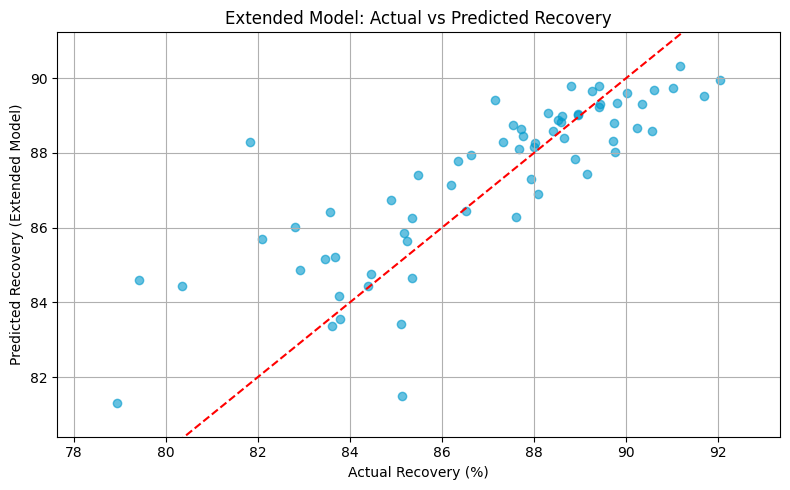

In [32]:
print(f"Rows before cleaning: {len(df)}")
df_clean = df.replace([np.inf, -np.inf], np.nan).dropna(
	subset=extended_features + ["Au_Recovery_pct"])
print(f"Rows after cleaning: {len(df_clean)}")

X = df_clean[extended_features]
y = df_clean["Au_Recovery_pct"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
													random_state=random_seed)

model_extended = RandomForestRegressor(n_estimators=100, random_state=random_seed)
model_extended.fit(X_train, y_train)

y_pred = model_extended.predict(X_test)

print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")

pf.plot_actual_vs_predicted_scatter(
	y_actual=y_test * 100,
	y_pred=y_pred * 100,
	title="Extended Model: Actual vs Predicted Recovery",
	xlabel="Actual Recovery (%)",
	ylabel="Predicted Recovery (Extended Model)",
	fig_size=(8, 5),
	autoscale_x=True,
	autoscale_y=True
)

### Updated Model Performance

| Metric   | Value  | Interpretation                                            |
| -------- | ------ | --------------------------------------------------------- |
| **R²**   | 0.649  | Strong — explains \~65% of recovery variance              |
| **RMSE** | 0.0177 | \~1.8% error — solid performance for operational use case |


What This Means
* The new engineered features improved accuracy (R² from 0.577 → 0.649, RMSE from 2.01% → 1.77%).
* This suggests the model benefits from interactions and ratios between core process variables - especially when contextualised by feed grade.
* The features `CN_per_grade`, `PSD_grade_ratio`, and `O2_to_CN` likely help counteract spurious inverse correlations seen earlier.
* Further gains may now require:
	- Additional process signals (carbon concentration, tails CN, CIL circuit parameters),
	- Time-lagged effects (e.g. prior day's CN dose or recovery),
	- Or kinetic model integration as hybrid model inputs (e.g. predicted vs actual recovery gap).

## CN × O₂ Sensitivity Surface

### Setup base row and grid

In [33]:
# Pick a representative base row
base_row = df_clean[extended_features].iloc[0].copy()

# Define CN and O₂ ranges
cn_values = np.linspace(50, 500, 20)
o2_values = np.linspace(2, 10, 20)

# Create meshgrid
CN_grid, O2_grid = np.meshgrid(cn_values, o2_values)

 ###  Compute predictions for each grid point

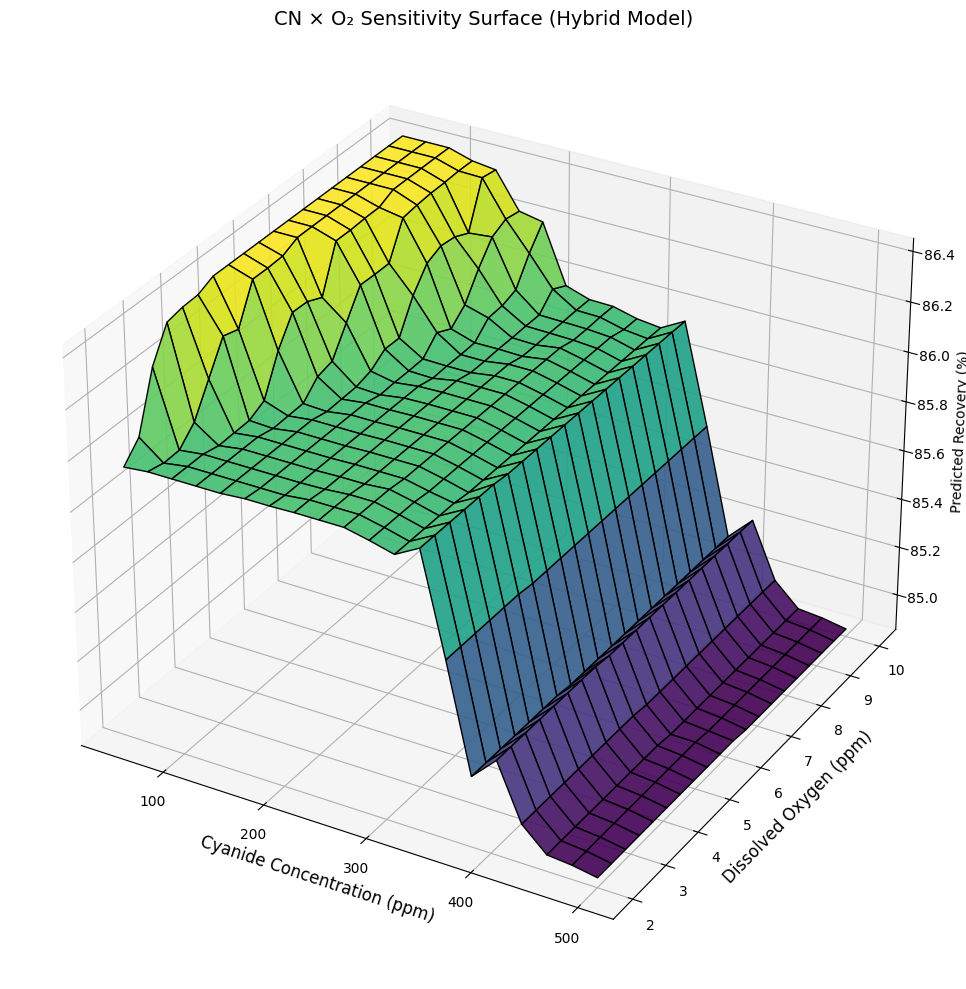

In [34]:
# Prepare container for predicted recovery
Recovery_grid = np.zeros_like(CN_grid)

# Loop over the grid and simulate
for i in range(CN_grid.shape[0]):
	for j in range(CN_grid.shape[1]):
		row = base_row.copy()

		row["Leach_Cn_Adds_ppm"] = CN_grid[i, j]
		row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed"] = O2_grid[i, j]

		# Update derived features
		row["CN_per_grade"] = row["Leach_Cn_Adds_ppm"] / row["Leach_Feed_Grade_Au_Gt_Day"]
		row["PSD_grade_ratio"] = (row["Effective_Particle_Size_um"] / 
							row["Leach_Feed_Grade_Au_Gt_Day"])
		row["O2_to_CN"] = (row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed"] / 
					 row["Leach_Cn_Adds_ppm"])

		# Update L&H kinetic output
		row["Modelled_Recovery_LH_Fitted"] = simulate_lh_recovery_fitted(
			row["Leach_Feed_Grade_Au_Gt_Day"],
			row["Effective_Particle_Size_um"],
			row["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed"],
			row["Leach_Cn_Adds_ppm"], n_tanks, locked_gold_threshold,
			total_residence_time, k1_fit, k2_fit, a_fit, b_fit, c_fit, d_exp_fit,
			max_dissolution_rate
		)

		# Predict recovery
		X_row = pd.DataFrame([row[extended_features]])
		Recovery_grid[i, j] = model_extended.predict(X_row)[0]

pf.plot_surface_sensitivity(
    CN_grid,
    O2_grid,
    Recovery_grid,
	fig_size = (12, 10),
    xlabel = "Cyanide Concentration (ppm)",
    ylabel = "Dissolved Oxygen (ppm)",
    zlabel = "Predicted Recovery",
    title = "CN × O₂ Sensitivity Surface (Hybrid Model)",
    scale_z_as_pct = True,
	scaling_factor = 100
)

### Plot the surface

### 🧠 Interpretation:
Observations:
1. Recovery declines at high CN concentrations
	* Likely a residual artefact from training data where high CN was used during difficult leach conditions.
	* This highlights operational confounding: CN isn’t the cause of low recovery, it was a response to it.

2. O₂ has a weak or slightly positive effect
	* Flat gradient across the O₂ axis suggests limited influence in your model, likely due to narrow range or low correlation in the dataset.
3. Best predicted recovery occurs at moderate CN (~150–250 ppm) and moderate-to-high O₂
	* This is encouraging — it aligns with practical experience.

### Residual and Error Analysis

R²: 0.8815958278112261
MAE: 0.005927385139168468
RMSE: 0.009614904343889162


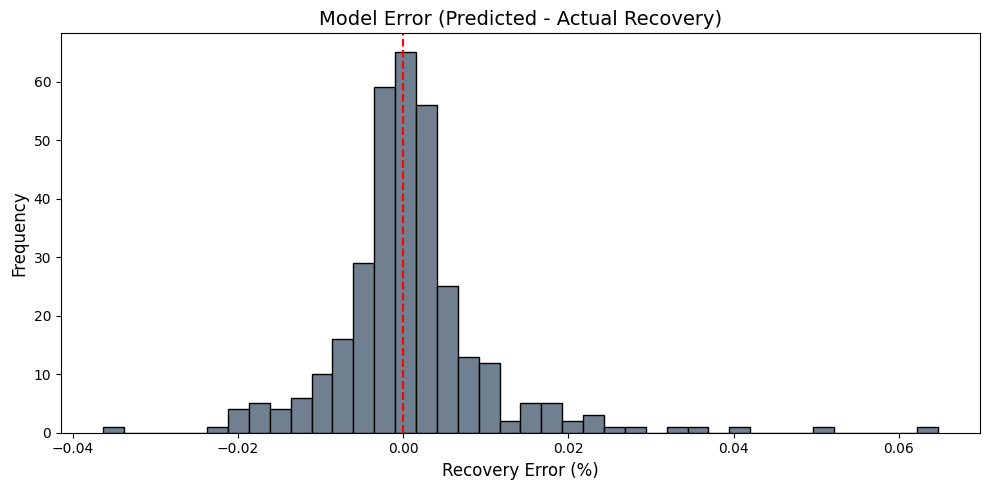

In [35]:
df_clean["Recovery_Predicted"] = model_extended.predict(df_clean[extended_features])
df_clean["Recovery_Error"] = df_clean["Recovery_Predicted"] - df_clean["Au_Recovery_pct"]

# Summary metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("R²:", r2_score(df_clean["Au_Recovery_pct"], df_clean["Recovery_Predicted"]))
print("MAE:", mean_absolute_error(df_clean["Au_Recovery_pct"],
								  df_clean["Recovery_Predicted"]))
print("RMSE:", root_mean_squared_error(df_clean["Au_Recovery_pct"],
									   df_clean["Recovery_Predicted"]))

pf.plot_histogram(
    data=df_clean["Recovery_Error"],
    bins=40,
    title="Model Error (Predicted - Actual Recovery)",
    xlabel="Recovery Error (%)",
    color="slategray",
    edgecolor="black",
    show_vline=True,
    vline_value=0,
    vline_style={"color": "red", "linestyle": "--"}
)

### Validation Summary
| Metric   | Value  | Interpretation                                                 |
| -------- | ------ | -------------------------------------------------------------- |
| **R²**   | 0.882  | Model explains 88% of recovery variance — **very strong**       |
| **MAE**  | 0.0059 | Mean error is ~0.59% recovery — within typical plant noise      |
| **RMSE** | 0.0096 | Low variance in errors — rare outliers, stable performance      |

### 🧠 Interpretation:
* Errors are sharply centred around zero,
* Minor under-prediction tail (left side), consistent with model conservatism,
* Error distribution is symmetric and narrow — indicating **well-generalised** model behaviour.

### Plot Actual vs Predicted Recovery Over Time

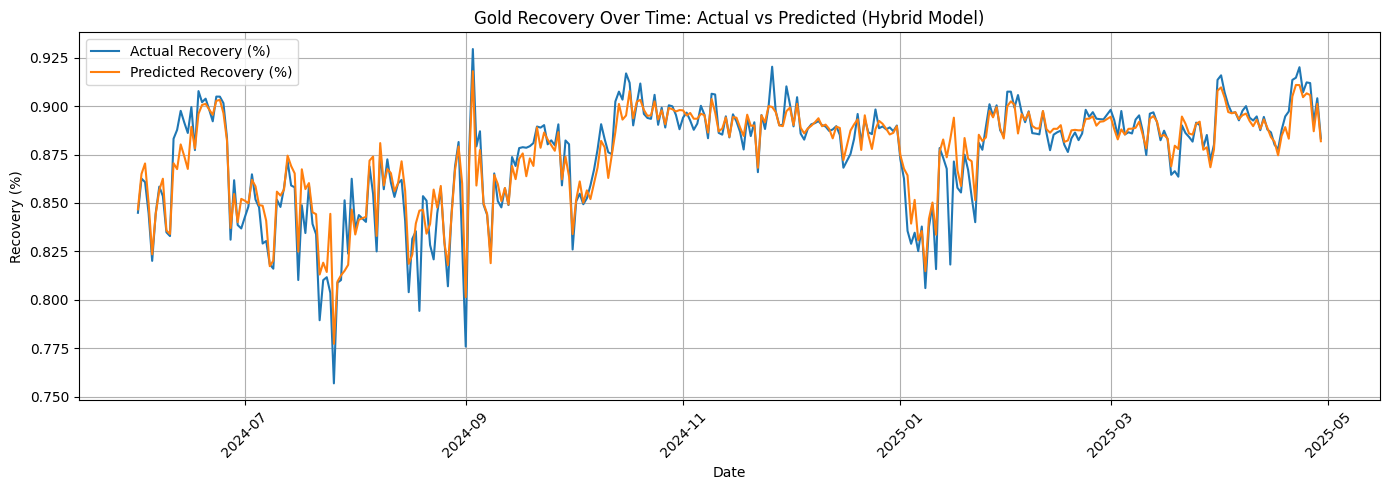

In [36]:
pf.plot_multiple_lines(
    df=df_clean,
    x_col="Date",
    y_series=[
        {"col": "Au_Recovery_pct", "label": "Actual Recovery (%)"},
        {"col": "Recovery_Predicted", "label": "Predicted Recovery (%)"}
    ],
    title="Gold Recovery Over Time: Actual vs Predicted (Hybrid Model)",
    x_label="Date",
    y_label="Recovery (%)",
    fig_size=(14, 5),
    colours=["#1f77b4", "#ff7f0e"]
)

### 🧠 Interpretation:
* The model generalises well - no drifting or chronic bias.
* Predictions are responsive to real operational changes.
* Even during step-changes or volatility, predictions stay within a ~±2% margin.
* Validates model robustness

### Compute residuals and flag large errors

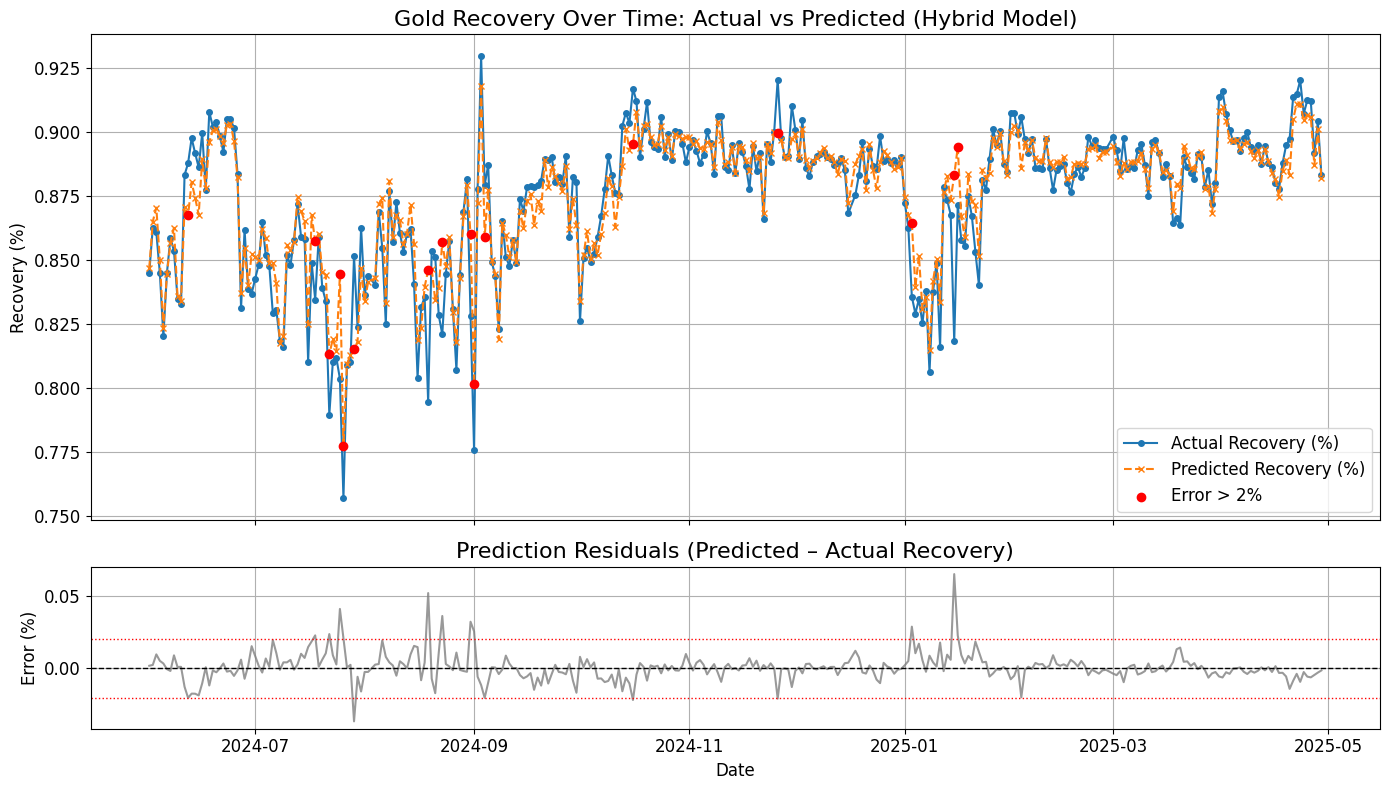

In [39]:
# Calculate residuals
df_clean["Recovery_Error"] = df_clean["Recovery_Predicted"] - df_clean["Au_Recovery_pct"]
df_clean["High_Error"] = df_clean["Recovery_Error"].abs() > 0.02

pf.plot_dual_panel_diagnostics(
	df = df_clean,
	date_col = "Date",
	col_1="Au_Recovery_pct",
	col_2="Recovery_Predicted",
    col_1_label = "Actual Recovery (%)",
	col_2_label = "Predicted Recovery (%)",
    ylabel_main = "Recovery (%)",
    xlabel = "Date",
	residual_col = "Recovery_Error",
	high_error_col = "High_Error",
	error_threshold = 0.02,
	title_main = "Gold Recovery Over Time: Actual vs Predicted (Hybrid Model)",
	title_residuals = "Prediction Residuals (Predicted – Actual Recovery)",
    title_font_size = 16,
    save_fig = True,
	save_path = "gold_recovery_diagnostics.png"
)

### 🧠 Interpretation:
**Top Panel - Actual vs Predicted Recovery:**
* The predicted recovery tracks the actual recovery closely over nearly a year of daily data, indicating strong model alignment.
* Only a small number of red-highlighted points (error > 2%) appear, and they are scattered rather than clustered - this suggests low volatility and temporal stability in prediction accuracy.
* Minor discrepancies are visible during sharp recovery transitions, but no persistent over- or under-prediction is evident.

**Bottom Panel - Residual Analysis:**
* The majority of residuals fall comfortably within ±1%, suggesting tight predictive tolerance.
* The residual distribution oscillates evenly around zero, with no systemic drift or bias.
* A few high-error spikes are observed, but they are not sustained, indicating isolated deviations rather than model breakdowns.


### Count and summarise high-error cases

In [40]:
high_error_count = df_clean["High_Error"].sum()
total_rows = len(df_clean)
print(f"{high_error_count} of {total_rows} days ({100 * high_error_count / total_rows:.2f}%) exceed ±2% prediction error.")

16 of 330 days (4.85%) exceed ±2% prediction error.


# Save model and dataframe

In [42]:
# Save model
import joblib
joblib.dump(model_extended, "shanta_recovery_model.pkl")
print("Model saved as shanta_recovery_model.pkl")

# Save processed DataFrame
df_clean.to_csv("shanta_recovery_data.csv", index=False)
print("Processed data saved as shanta_recovery_data.csv")

Model saved as shanta_recovery_model.pkl
Processed data saved as shanta_recovery_data.csv


## Visualise Recovery vs Grade & CN Concentration

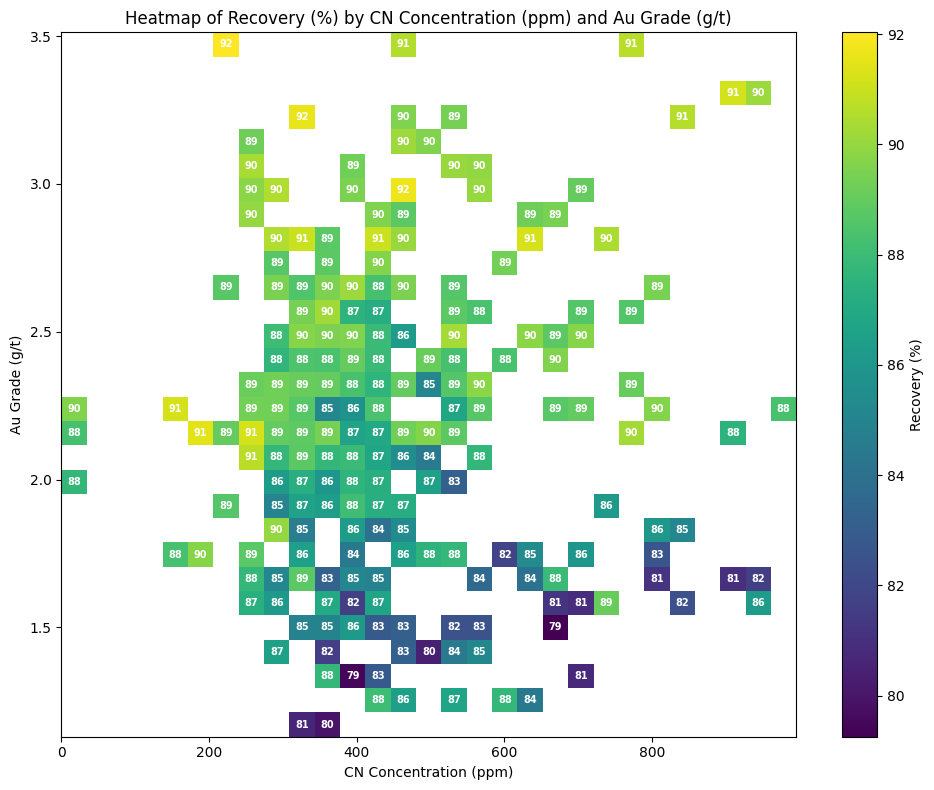

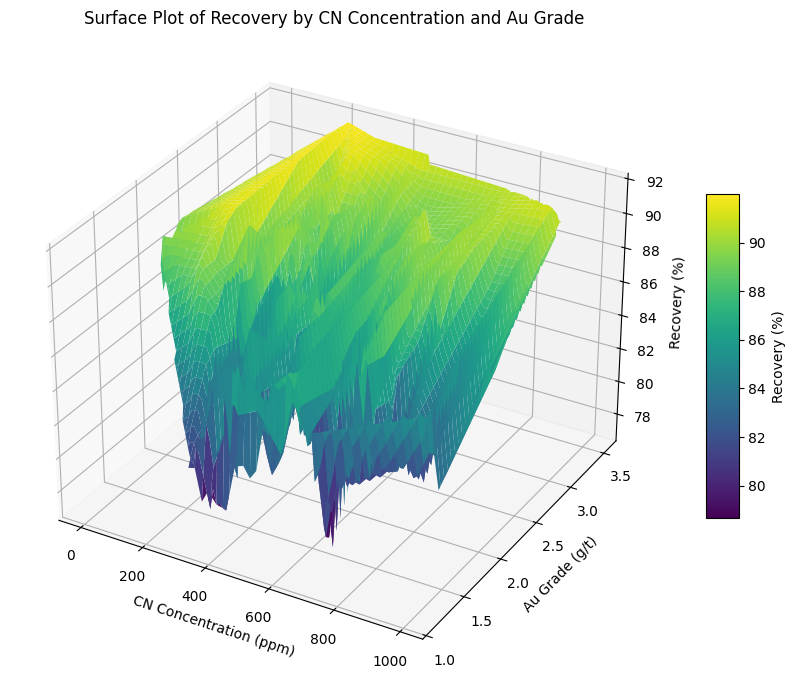

In [43]:
pf.plot_heatmap(
    df=df,
    x_field="Leach_Cn_Adds_ppm",
    y_field="Leach_Feed_Grade_Au_Gt_Day",
    z_field="Au_Recovery_pct",
    x_label="CN Concentration (ppm)",
    y_label="Au Grade (g/t)",
    z_label="Recovery (%)"
)

pf.plot_surface(
    df=df,
    x_field="Leach_Cn_Adds_ppm",
    y_field="Leach_Feed_Grade_Au_Gt_Day",
    z_field="Au_Recovery_pct",
    x_label="CN Concentration (ppm)",
    y_label="Au Grade (g/t)",
    z_label="Recovery (%)",
    title="Surface Plot of Recovery by CN Concentration and Au Grade",
    grid_points=100,          # resolution of the surface
    clip_range=(70, 95)       # clip interpolated recovery values to valid % range
)

## Compare Au Recovery vs Grade & CN Usage

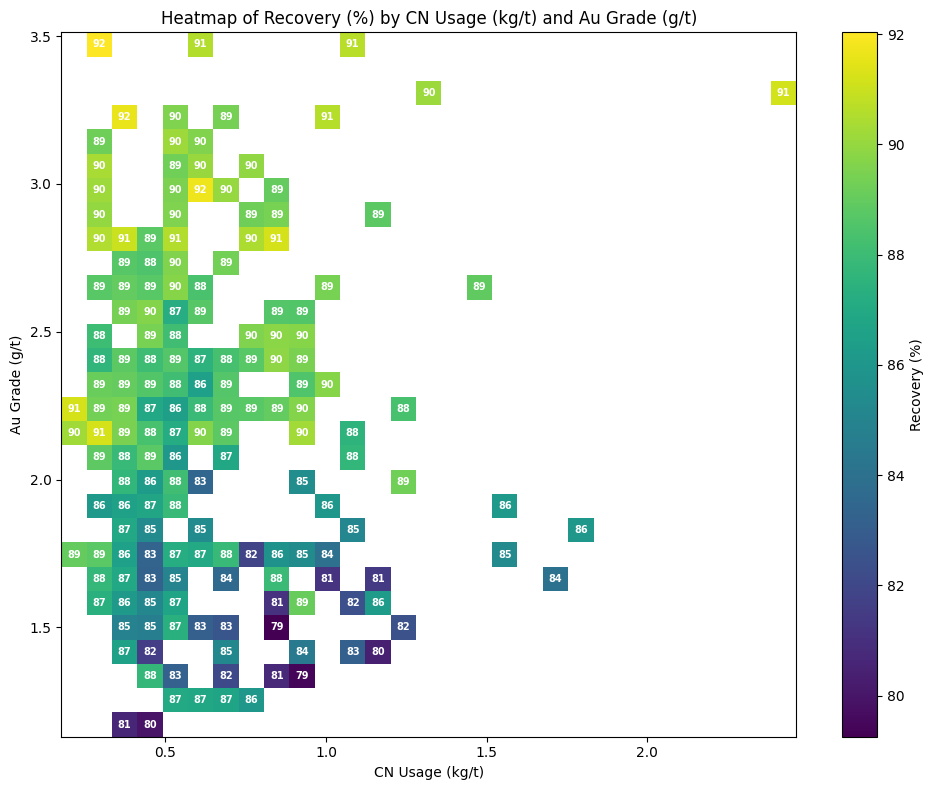

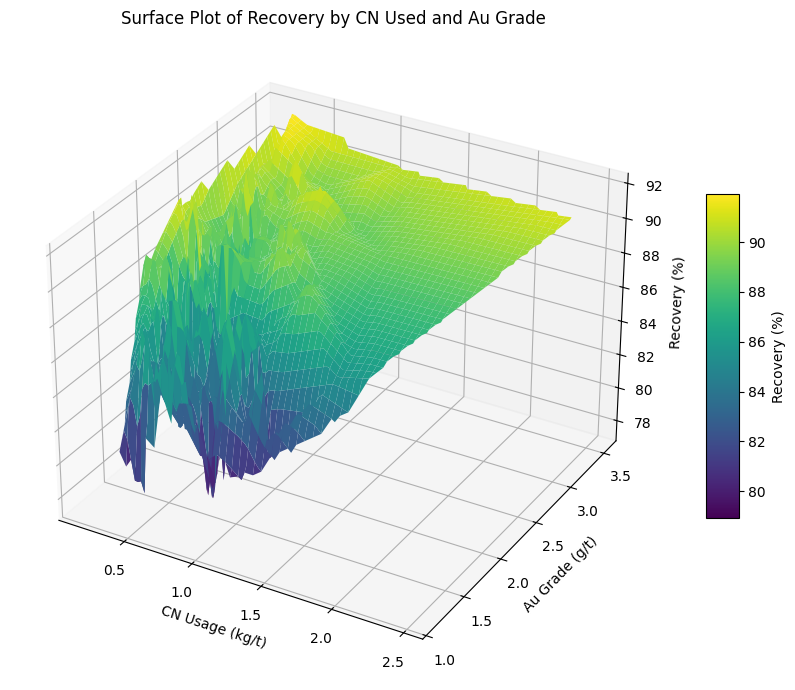

In [56]:
df_diag = df.copy()
df_diag["CN_Usage_per_t"] = df_diag["Estimated_NaCN_Used_Kg_Scaled"] / df_diag["Daily_Milledtreated_Tons"]

df_diag["CN_Usage_per_t"].describe()

# Drop rows with NaN or infinite or zero values in CN usage
df_diag = df_diag.replace([np.inf, -np.inf], np.nan).dropna(subset=["CN_Usage_per_t"])
df_diag = df_diag[df_diag["CN_Usage_per_t"] > 0].copy()

pf.plot_heatmap(
    df=df_diag,
    x_field="CN_Usage_per_t",
    y_field="Leach_Feed_Grade_Au_Gt_Day",
    z_field="Au_Recovery_pct",
    x_label="CN Usage (kg/t)",
    y_label="Au Grade (g/t)",
    z_label="Recovery (%)"
)

pf.plot_surface(
    df=df_diag,
    x_field="CN_Usage_per_t",
    y_field="Leach_Feed_Grade_Au_Gt_Day",
    z_field="Au_Recovery_pct",
    x_label="CN Usage (kg/t)",
    y_label="Au Grade (g/t)",
    z_label="Recovery (%)",
    title="Surface Plot of Recovery by CN Used and Au Grade",
    grid_points=100,
    clip_range=(75, 95)
)


### 🧠 Interpretation:
**1. General Observations**
* Recovery continues to **increase with gold grade**, with values above ~2.5 g/t consistently yielding >90% recovery.
* CN usage also shows a positive relationship with recovery, but this effect is **more sharply diminishing** compared to concentration-based plots.

**2. Heatmap Observations**
* Recoveries mostly range from 85–91%, with upper bins (≥ 91%) appearing at **high grade and modest CN usage** levels (~0.3–0.7 kg/t).
* At lower grades (<1.8 g/t), increased CN usage **does not always translate** into better recovery - particularly past ~0.8 kg/t, indicating diminishing returns or inefficiencies.
* Sparse data in high usage bins (>1.5 kg/t) suggests these scenarios are rare or atypical in the dataset.

**3. Surface Plot Observations**
* The recovery surface shows:
    - A **strong** vertical slope along the Au grade axis.
    - A **flattening plateau** beyond ~0.8–1.0 kg/t NaCN usage.
* Local surface irregularities may reflect operational noise or inconsistent dosing relative to ore characteristics.

**4. Comparison with Concentration-Based Visualisation**
* Compared to the CN concentration-based plots:
    - The **recovery trend with CN usage is steeper** at low doses, but plateaus faster.
    - This reinforces that **optimising total CN added per tonne** is more meaningful than simply targeting solution strength (ppm).
    - High CN usage does not guarantee better recovery, especially for lower grade ore — and may indicate overdosing or **ineffective utilisation**.

5. Operational Takeaway
* Maximum efficiency appears to occur at:
    - **CN usage levels between 0.4–0.8 kg/t**, and
    - **Gold grades >2.5 g/t**.
* These plots support a **dose-to-performance optimisation** framework, suggesting there may be **cost savings** available by capping NaCN usage where recovery benefit has already plateaued.

In [57]:
pf.plot_comparative_heatmap_surface(
    df=df,
    left_fields={
        "x_field": "Leach_Cn_Adds_ppm",
        "y_field": "Leach_Feed_Grade_Au_Gt_Day",
        "z_field": "Au_Recovery_pct",
        "x_label": "CN Concentration (ppm)",
        "y_label": "Au Grade (g/t)",
        "z_label": "Actual Recovery (%)"
    },
    right_fields={
        "x_field": "Leach_Cn_Adds_ppm",
        "y_field": "Leach_Feed_Grade_Au_Gt_Day",
        "z_field": "Predicted_Recovery_Enhanced",
        "x_label": "CN Concentration (ppm)",
        "y_label": "Au Grade (g/t)",
        "z_label": "Predicted Recovery (%)"
    },
    bins=30,
    grid_points=100,
    clip_range=(70, 95)
)

KeyError: "['Predicted_Recovery_Enhanced'] not in index"

In [47]:
df.columns.to_list()

['Date',
 'Leach_Feed_Throughput_M3Hr',
 'Leach_Feed_Throughput_M3Day',
 'Percentsolids',
 'Leach_Feed_Grade_Au_Gt_Ds',
 'Leach_Feed_Grade_Au_Gt_Ns',
 'Leach_Feed_Grade_Au_Gt_Day',
 'Leach_Feed_Grade_Ag_Gt_Ds',
 'Leach_Feed_Grade_Ag_Gt_Ns',
 'Leach_Feed_Grade_Ag_Gt_Day',
 'Cn_Added_Free_Cn_Ppm_Leach_Tank_1',
 'Cn_Added_Free_Cn_Ppm_Leach_Tank_2',
 'Daily_Nacn_Consumption_Kgt',
 'Mtd_Nacn_Consumption_Kgt',
 'Nacn_Used_T',
 'Cil_Feed_Total_Au_Grams',
 'Cn_Conc_Tailing_Ppm',
 'Total_Au_Tailing_Grams',
 'Leach_Feed_Gt_150um_Day',
 'Leach_Feed_Gt_75um_Day',
 'Leach_Feed_Lt_75um_Day',
 'Cyanide_Profile_Ppm_Leach_Tank_1',
 'Cyanide_Profile_Ppm_Leach_Tank_2',
 'Cyanide_Profile_Ppm_Cil_Tank_01',
 'Cyanide_Profile_Ppm_Cil_Tank_02',
 'Cyanide_Profile_Ppm_Cil_Tank_03',
 'Cyanide_Profile_Ppm_Cil_Tank_04',
 'Cyanide_Profile_Ppm_Cil_Tank_05',
 'Cyanide_Profile_Ppm_Cil_Tank_06',
 'Cyanide_Profile_Ppm_Cil_Tank_07',
 'Cyanide_Profile_Ppm_Cil_Tank_08',
 'Cyanide_Profile_Ppm_Cil_Tank_09',
 'Dissolved_Oxyge

In [ ]:
pf.plot_comparative_heatmap_surface(
    df=df,
    left_fields={
        "x_field": "Leach_Cn_Adds_ppm",
        "y_field": "Leach_Feed_Grade_Au_Gt_Day",
        "z_field": "Au_Recovery_pct",
        "x_label": "CN Concentration (ppm)",
        "y_label": "Au Grade (g/t)",
        "z_label": "Actual Recovery (%)"
    },
    right_fields={
        "x_field": "Leach_Cn_Adds_ppm",
        "y_field": "Leach_Feed_Grade_Au_Gt_Day",
        "z_field": "Recovery_Calibrated",
        "x_label": "CN Concentration (ppm)",
        "y_label": "Au Grade (g/t)",
        "z_label": "Predicted Recovery (%)"
    },
    bins=30,
    grid_points=100,
    clip_range=(70, 95)
)